In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import style
style.use('ggplot')

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('/content/4023671-CO2_Emissions_Canada.csv')
data.head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [ ]:
data.nunique()   # Number of category

,0
Make,42
Model,2053
Vehicle Class,16
Engine Size(L),51
Cylinders,8
Transmission,27
Fuel Type,5
Fuel Consumption City (L/100 km),211
Fuel Consumption Hwy (L/100 km),143
Fuel Consumption Comb (L/100 km),181


In [ ]:
data['Vehicle Class'].unique()    # All the unique value

array(['COMPACT', 'SUV - SMALL', 'MID-SIZE', 'TWO-SEATER', 'MINICOMPACT',
       'SUBCOMPACT', 'FULL-SIZE', 'STATION WAGON - SMALL',
       'SUV - STANDARD', 'VAN - CARGO', 'VAN - PASSENGER',
       'PICKUP TRUCK - STANDARD', 'MINIVAN', 'SPECIAL PURPOSE VEHICLE',
       'STATION WAGON - MID-SIZE', 'PICKUP TRUCK - SMALL'], dtype=object)

In [ ]:
# As we have to find all the unique value in all catagorical column we will be using loop

cols = ['Make','Vehicle Class','Fuel Type','Cylinders','Transmission',]
for col in cols:
  print(f'{col:20}: {data[col].dropna().unique()}')
  print('\n','-'*100)



''' f'{col:20}' (Alignment): This is an "f-string" with padding.
The :20 tells Python to reserve 20 spaces for the column name.
This ensures that all your colons (:) line up vertically, making the output easy to read.'''

'''.dropna() (Cleaning): This tells Pandas to ignore any missing or empty values (NaN).
Without this, "NaN" might show up as one of your unique categories.'''

'''.unique() (Filtering): This is the most important part. It looks at every row in that
column and returns only the distinct values. For example, if you have 1,000 "Toyota" cars, .unique()
will only show "Toyota" once.'''

Make                : ['ACURA' 'ALFA ROMEO' 'ASTON MARTIN' 'AUDI' 'BENTLEY' 'BMW' 'BUICK'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER' 'DODGE' 'FIAT' 'FORD' 'GMC' 'HONDA'
 'HYUNDAI' 'INFINITI' 'JAGUAR' 'JEEP' 'KIA' 'LAMBORGHINI' 'LAND ROVER'
 'LEXUS' 'LINCOLN' 'MASERATI' 'MAZDA' 'MERCEDES-BENZ' 'MINI' 'MITSUBISHI'
 'NISSAN' 'PORSCHE' 'RAM' 'ROLLS-ROYCE' 'SCION' 'SMART' 'SRT' 'SUBARU'
 'TOYOTA' 'VOLKSWAGEN' 'VOLVO' 'GENESIS' 'BUGATTI']

 ----------------------------------------------------------------------------------------------------
Vehicle Class       : ['COMPACT' 'SUV - SMALL' 'MID-SIZE' 'TWO-SEATER' 'MINICOMPACT'
 'SUBCOMPACT' 'FULL-SIZE' 'STATION WAGON - SMALL' 'SUV - STANDARD'
 'VAN - CARGO' 'VAN - PASSENGER' 'PICKUP TRUCK - STANDARD' 'MINIVAN'
 'SPECIAL PURPOSE VEHICLE' 'STATION WAGON - MID-SIZE'
 'PICKUP TRUCK - SMALL']

 ----------------------------------------------------------------------------------------------------
Fuel Type           : ['Z' 'D' 'X' 'E' 'N']

 -------------------

'.unique() (Filtering): This is the most important part. It looks at every row in that \ncolumn and returns only the distinct values. For example, if you have 1,000 "Toyota" cars, .unique() \nwill only show "Toyota" once.'

In [ ]:
 # To check Duplicates

data.duplicated().sum()

np.int64(1103)

In [ ]:
# Dropping the Duplicates

data.drop_duplicates(inplace = True)

In [ ]:
# To check foe the missing values

data.isnull().sum()           # Got no missing values

,0
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


------
------
 ## Data Visulation

------
------

In [ ]:
data.head(2)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221


<Axes: xlabel='Engine Size(L)', ylabel='CO2 Emissions(g/km)'>

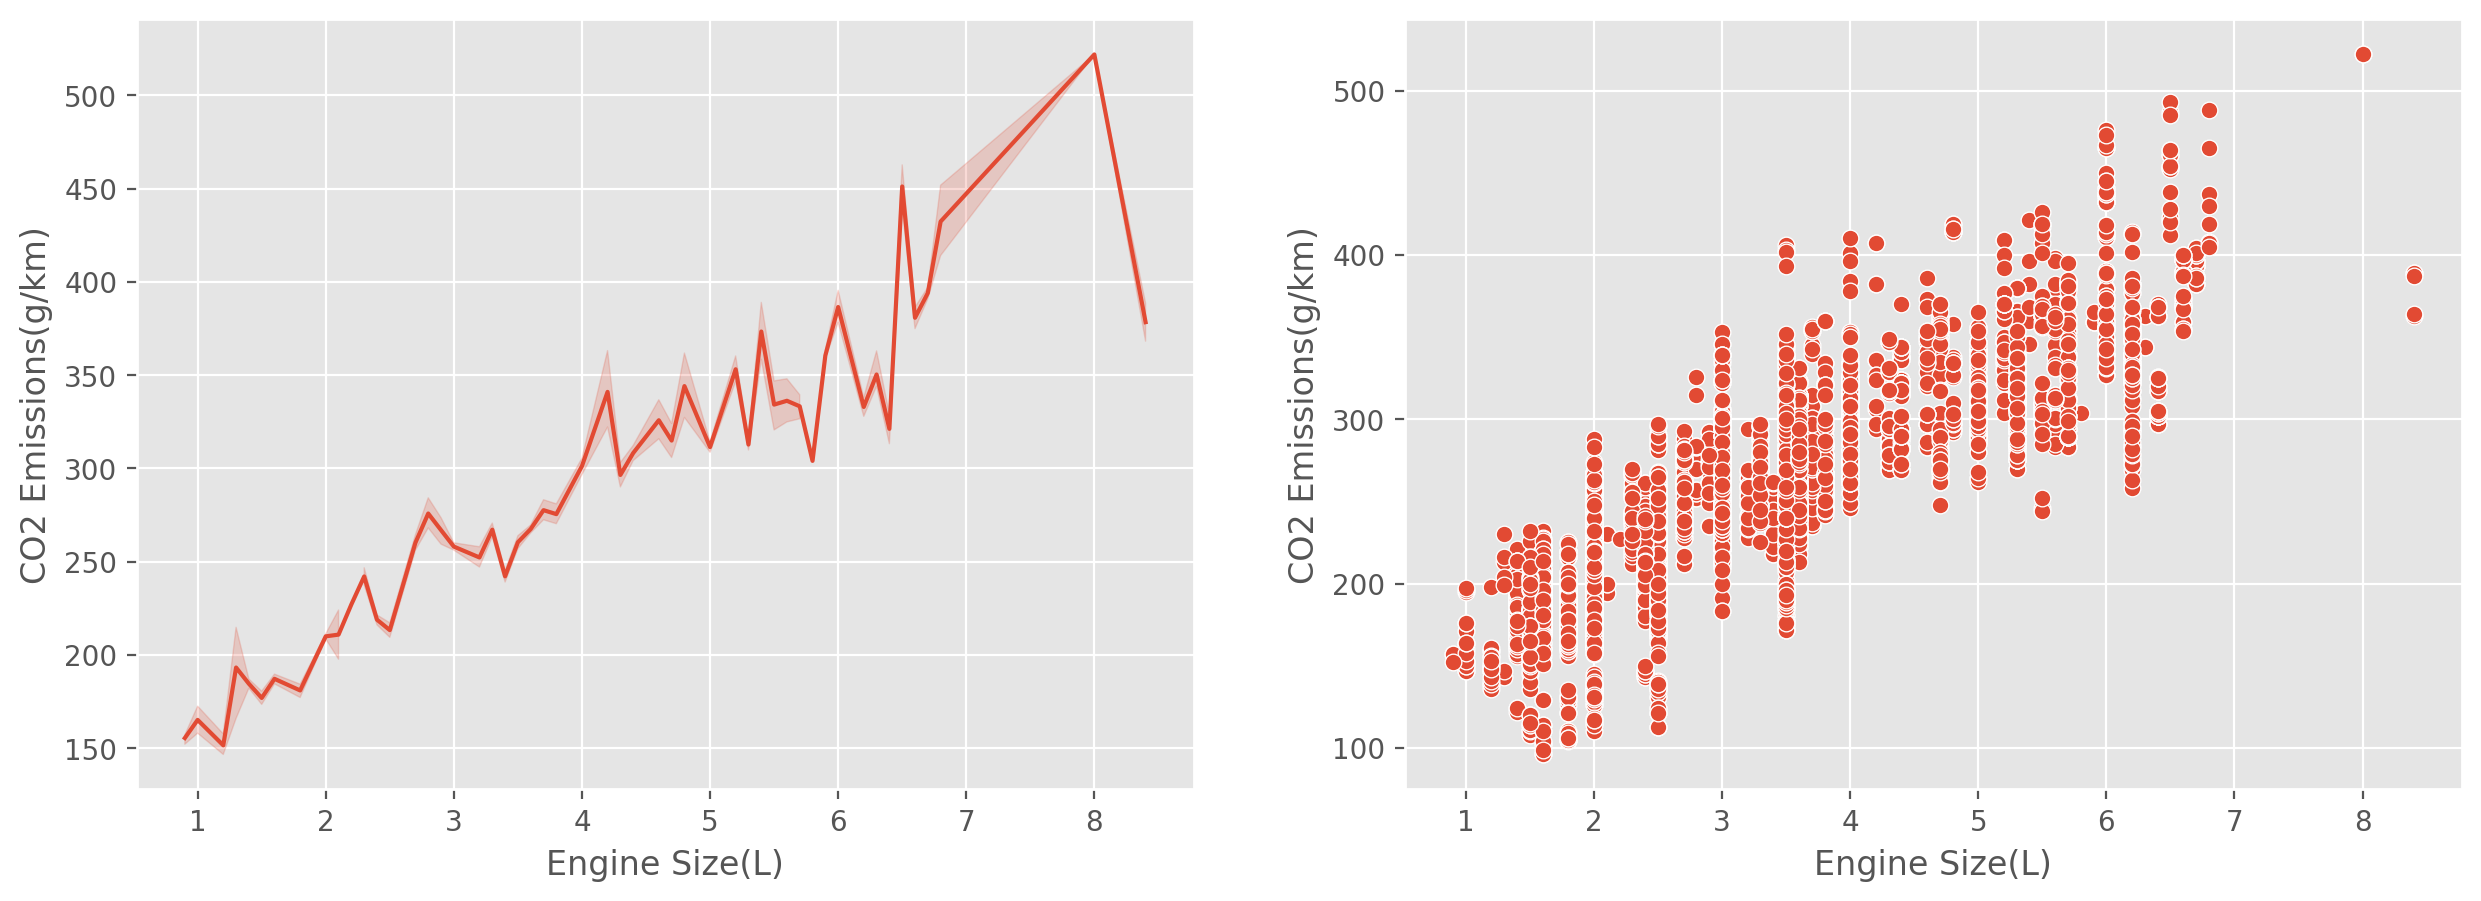

In [ ]:
# Engine size and co2 emission

plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.lineplot(x = 'Engine Size(L)', y = 'CO2 Emissions(g/km)', data = data)

plt.subplot(1,2,2)
sns.scatterplot(x = 'Engine Size(L)', y = 'CO2 Emissions(g/km)', data = data)

In [ ]:
# Corelation

data[['Engine Size(L)', 'CO2 Emissions(g/km)']].corr()

,Engine Size(L),CO2 Emissions(g/km)
Engine Size(L),1.000000,0.854802
CO2 Emissions(g/km),0.854802,1.000000


<Axes: xlabel='Cylinders', ylabel='CO2 Emissions(g/km)'>

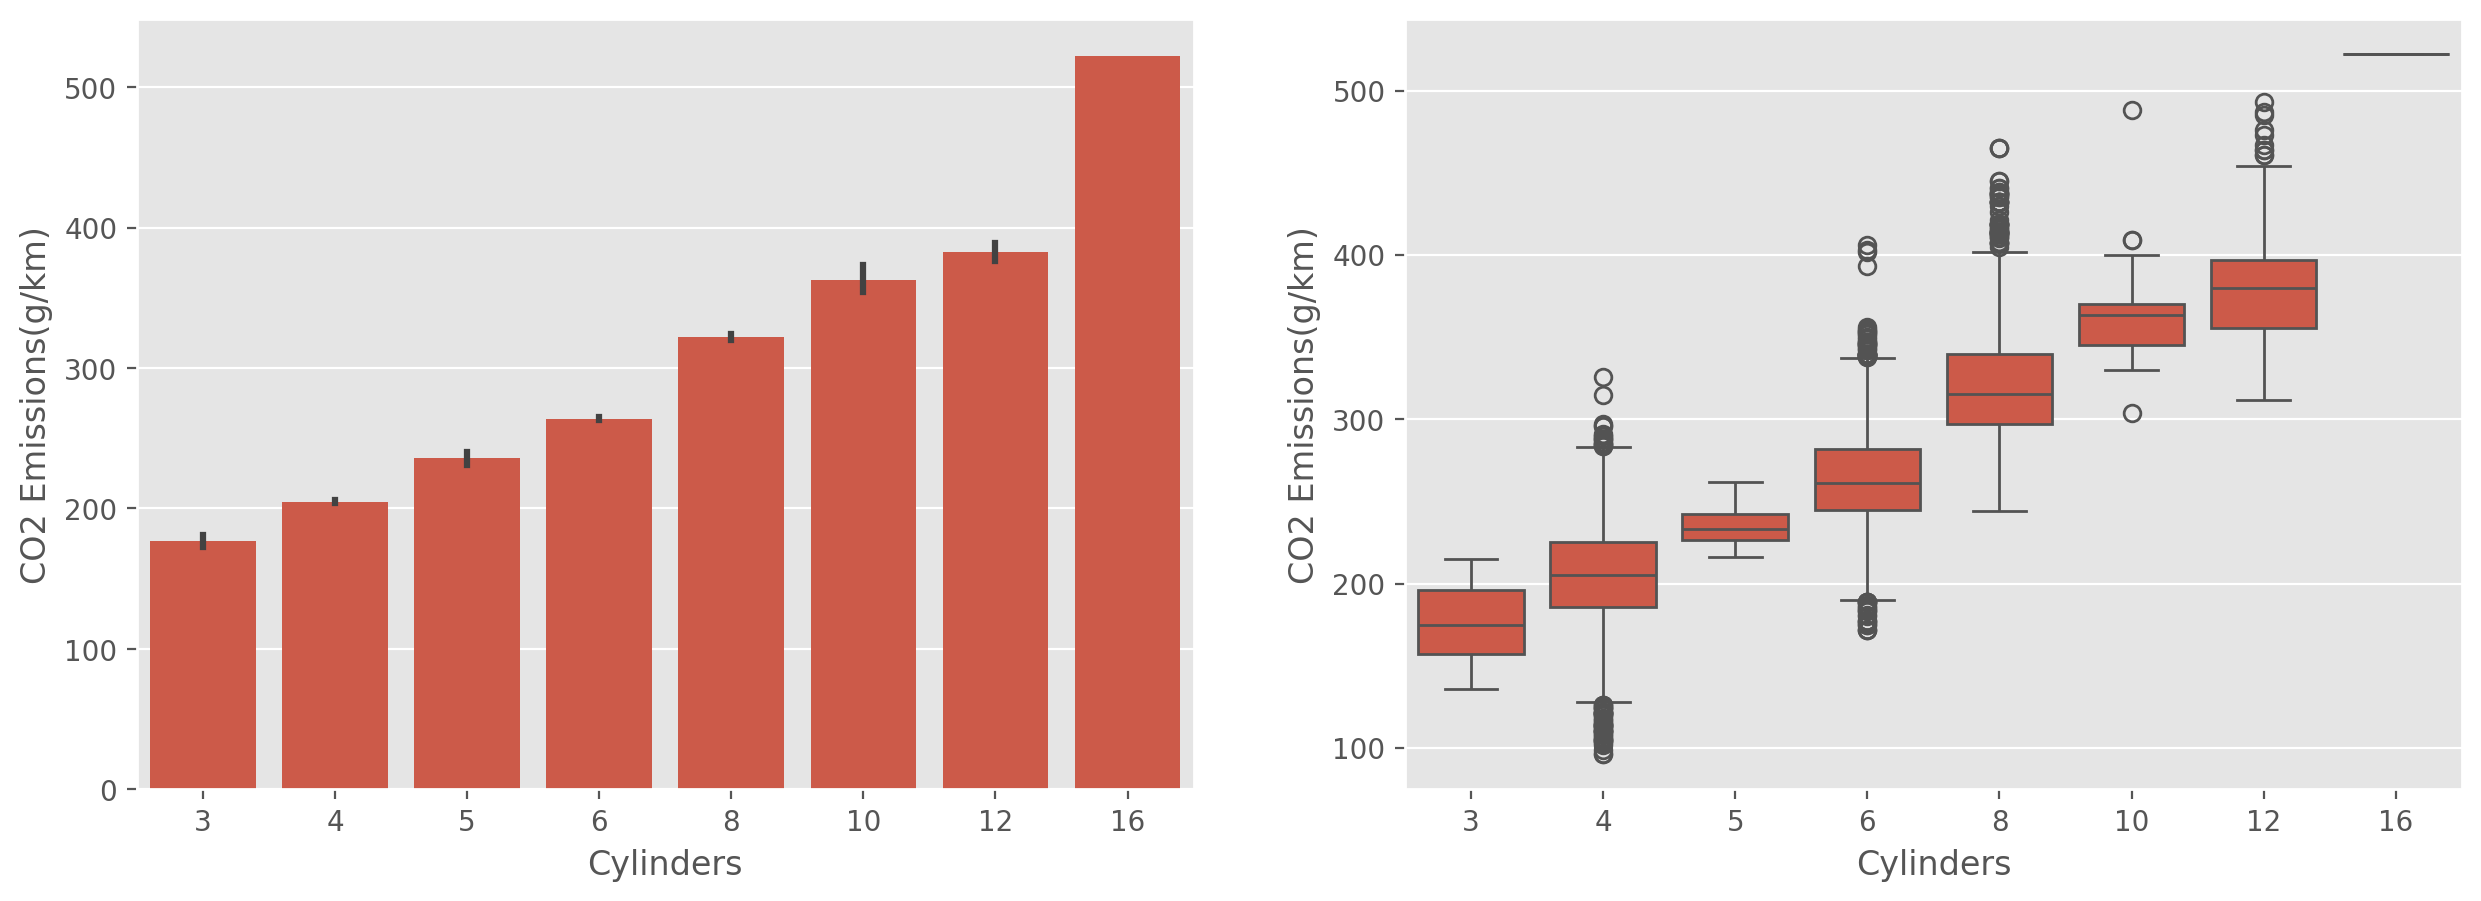

In [ ]:
# Cylinder and co2 Emission

plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.barplot(x = 'Cylinders', y = 'CO2 Emissions(g/km)', data = data)

plt.subplot(1,2,2)
sns.boxplot(x = 'Cylinders', y = 'CO2 Emissions(g/km)', data = data)


In [ ]:
# Avg carbon emission with respect to cylinder

data.groupby('Cylinders')['CO2 Emissions(g/km)'].mean().sort_values(ascending = False)

,CO2 Emissions(g/km)
Cylinders,
16,522.000000
12,382.659259
10,362.600000
8,321.912646
6,263.972059
5,235.692308
4,204.963623
3,176.715909


<Axes: xlabel='Fuel Type', ylabel='CO2 Emissions(g/km)'>

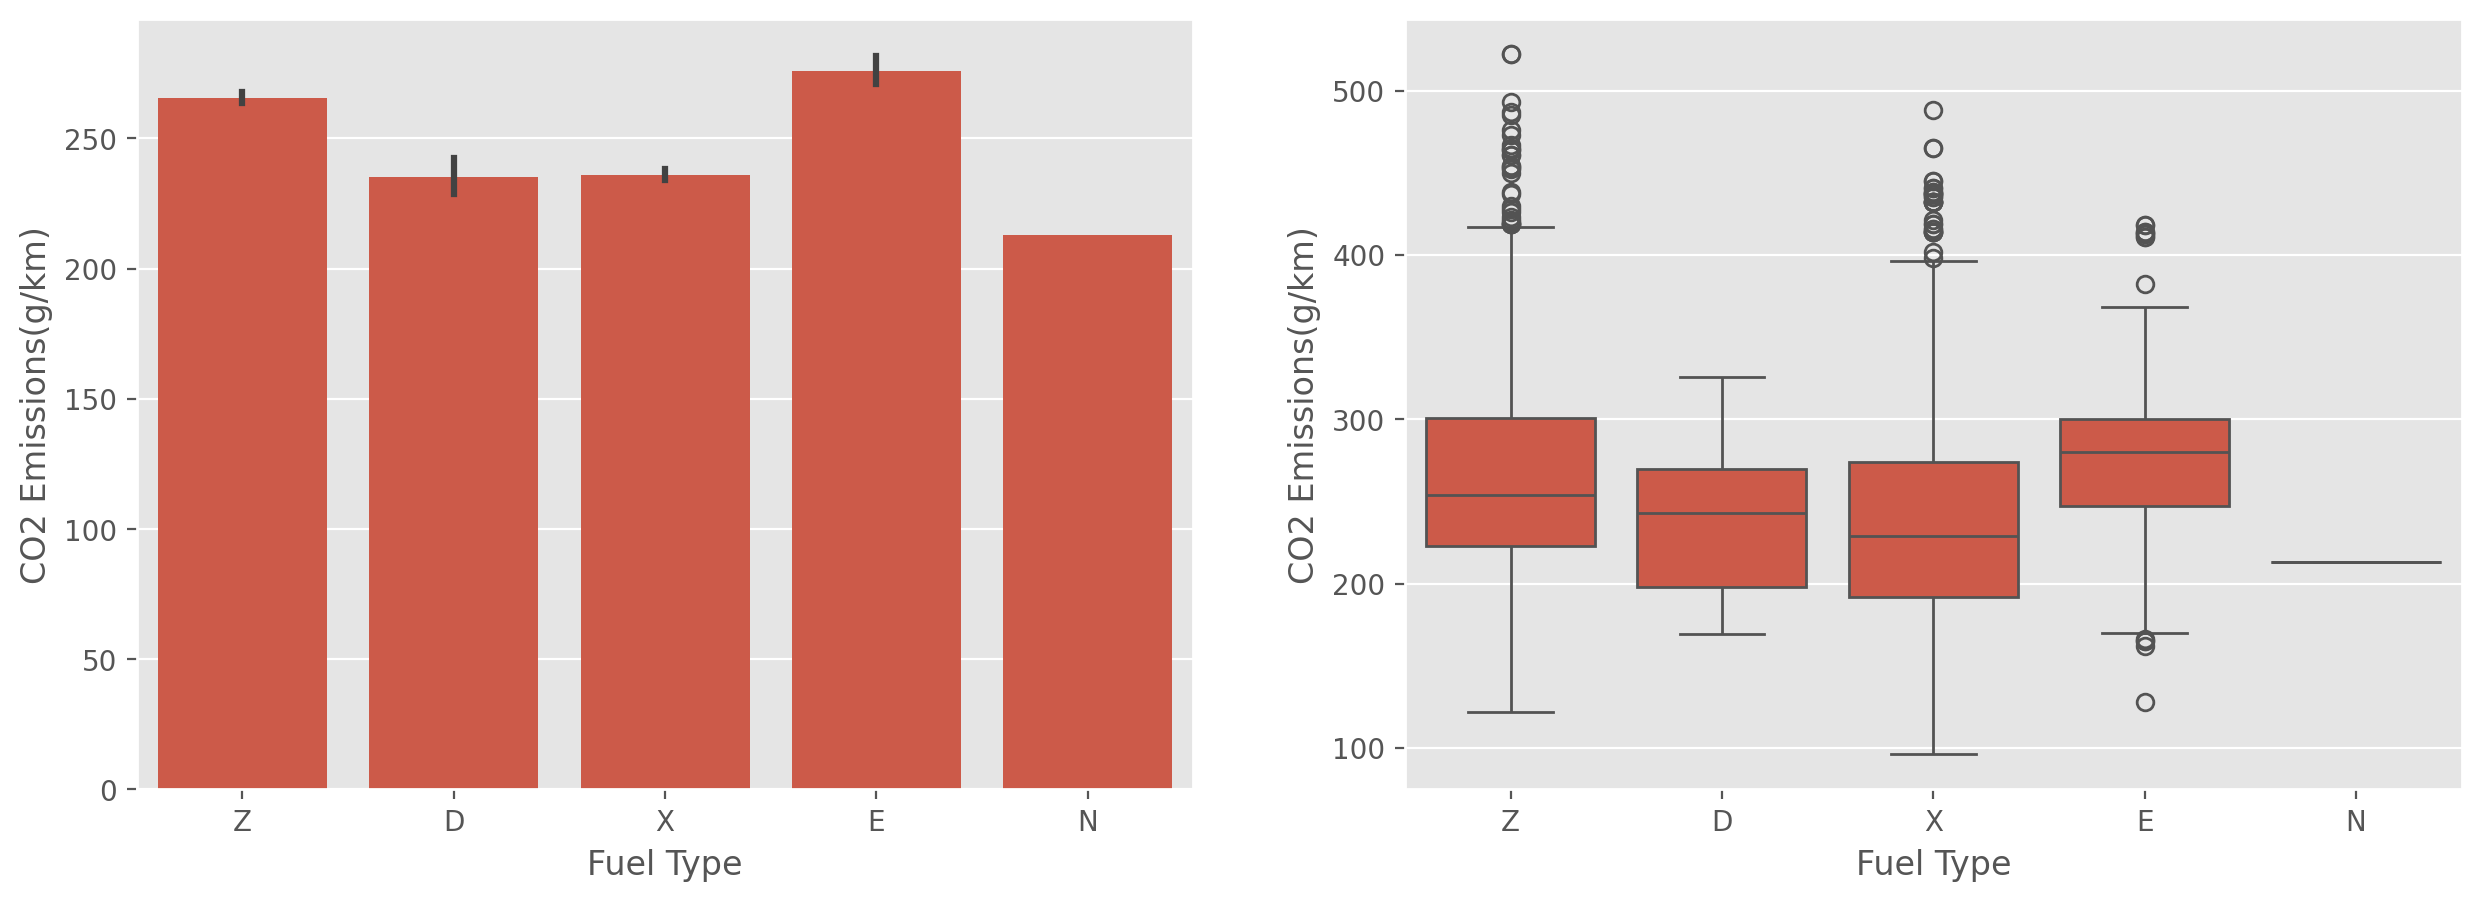

In [ ]:
# Fule type and co2 Emission

plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.barplot(x = 'Fuel Type', y = 'CO2 Emissions(g/km)', data = data)

plt.subplot(1,2,2)
sns.boxplot(x = 'Fuel Type', y = 'CO2 Emissions(g/km)', data = data)


In [ ]:
# Avg carbon emossion with fule type

data.groupby('Fuel Type')['CO2 Emissions(g/km)'].mean().sort_values(ascending = False)

,CO2 Emissions(g/km)
Fuel Type,
E,276.048485
Z,265.731284
X,235.977953
D,235.238095
N,213.000000


<Axes: xlabel='Fuel Consumption Comb (L/100 km)', ylabel='CO2 Emissions(g/km)'>

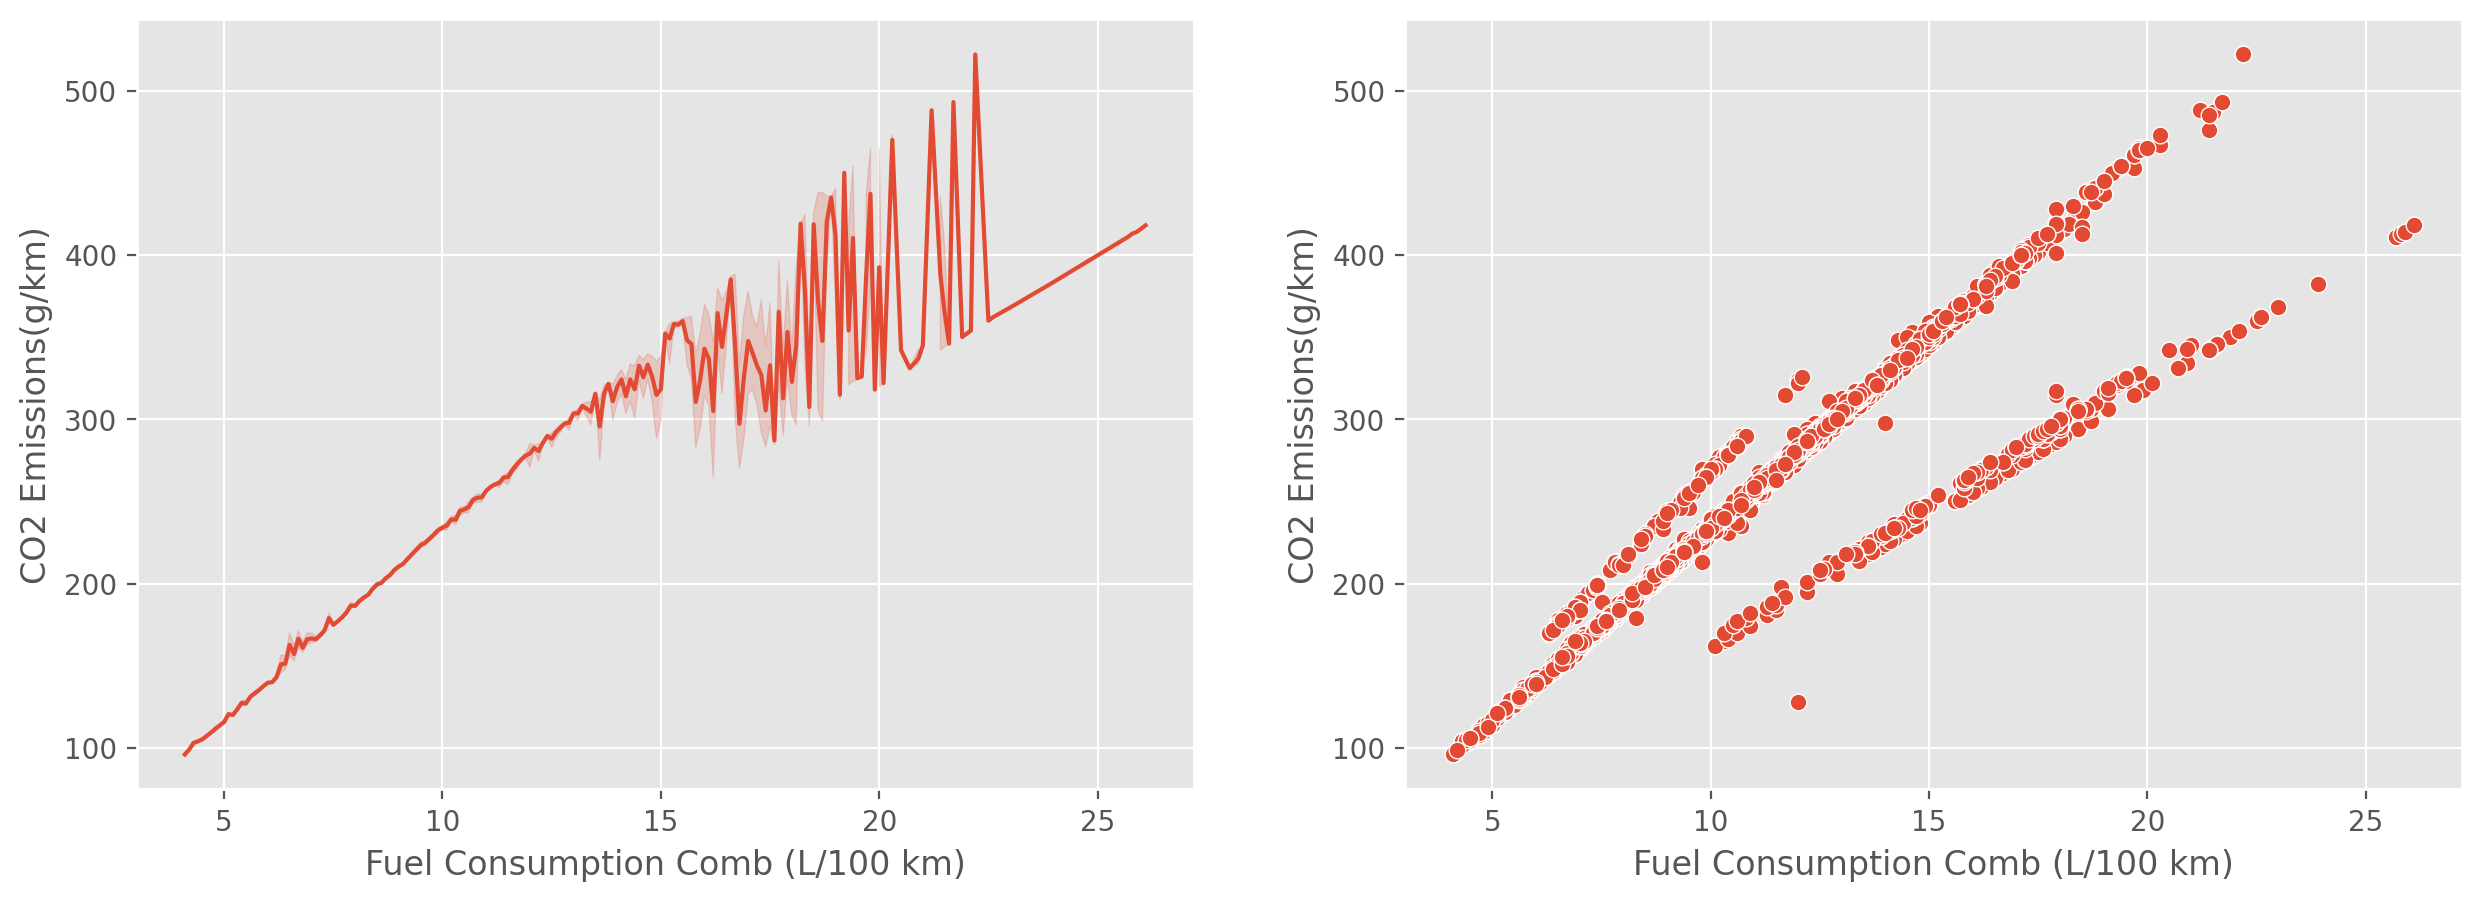

In [ ]:
 # Fule Consumption and co2 Emission

plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.lineplot(x = 'Fuel Consumption Comb (L/100 km)', y = 'CO2 Emissions(g/km)', data = data)

plt.subplot(1,2,2)
sns.scatterplot(x = 'Fuel Consumption Comb (L/100 km)', y = 'CO2 Emissions(g/km)', data = data)

<Axes: xlabel='Fuel Consumption Comb (L/100 km)', ylabel='CO2 Emissions(g/km)'>

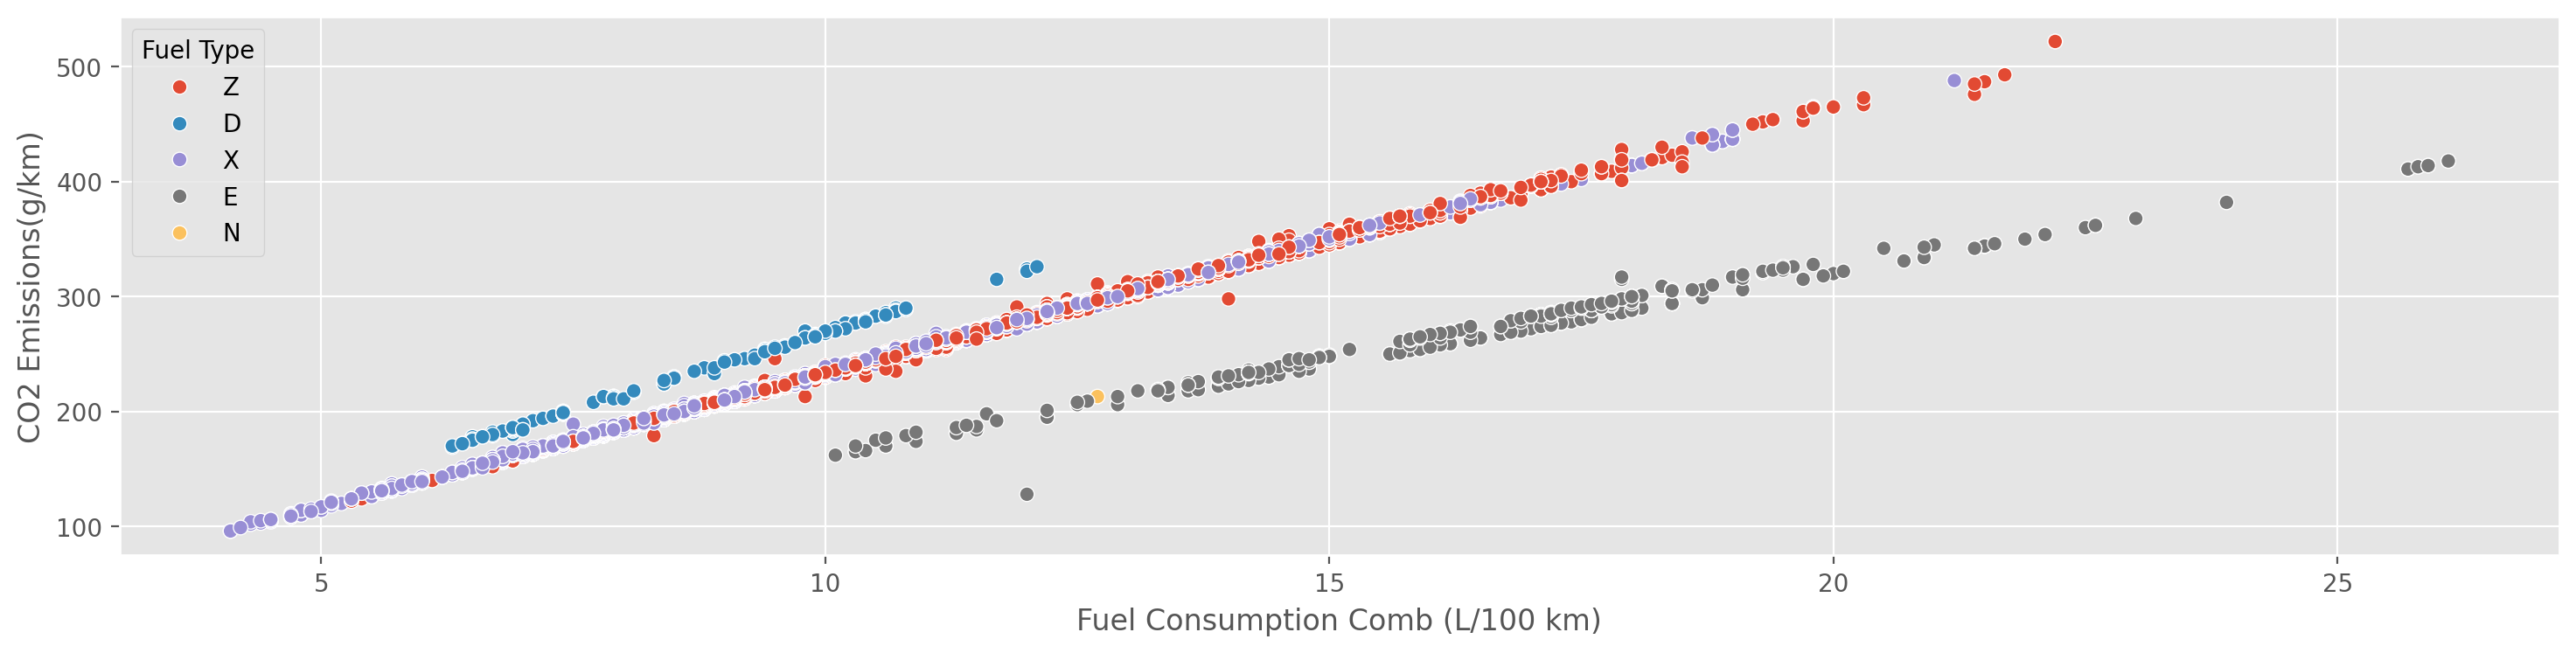

In [ ]:
# Reason we were getting 3 section in scatter plot

plt.figure(figsize = (18,4), dpi = 200)

sns.scatterplot(x = 'Fuel Consumption Comb (L/100 km)', y = 'CO2 Emissions(g/km)', data = data , hue = 'Fuel Type')

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Vehicle Class'>

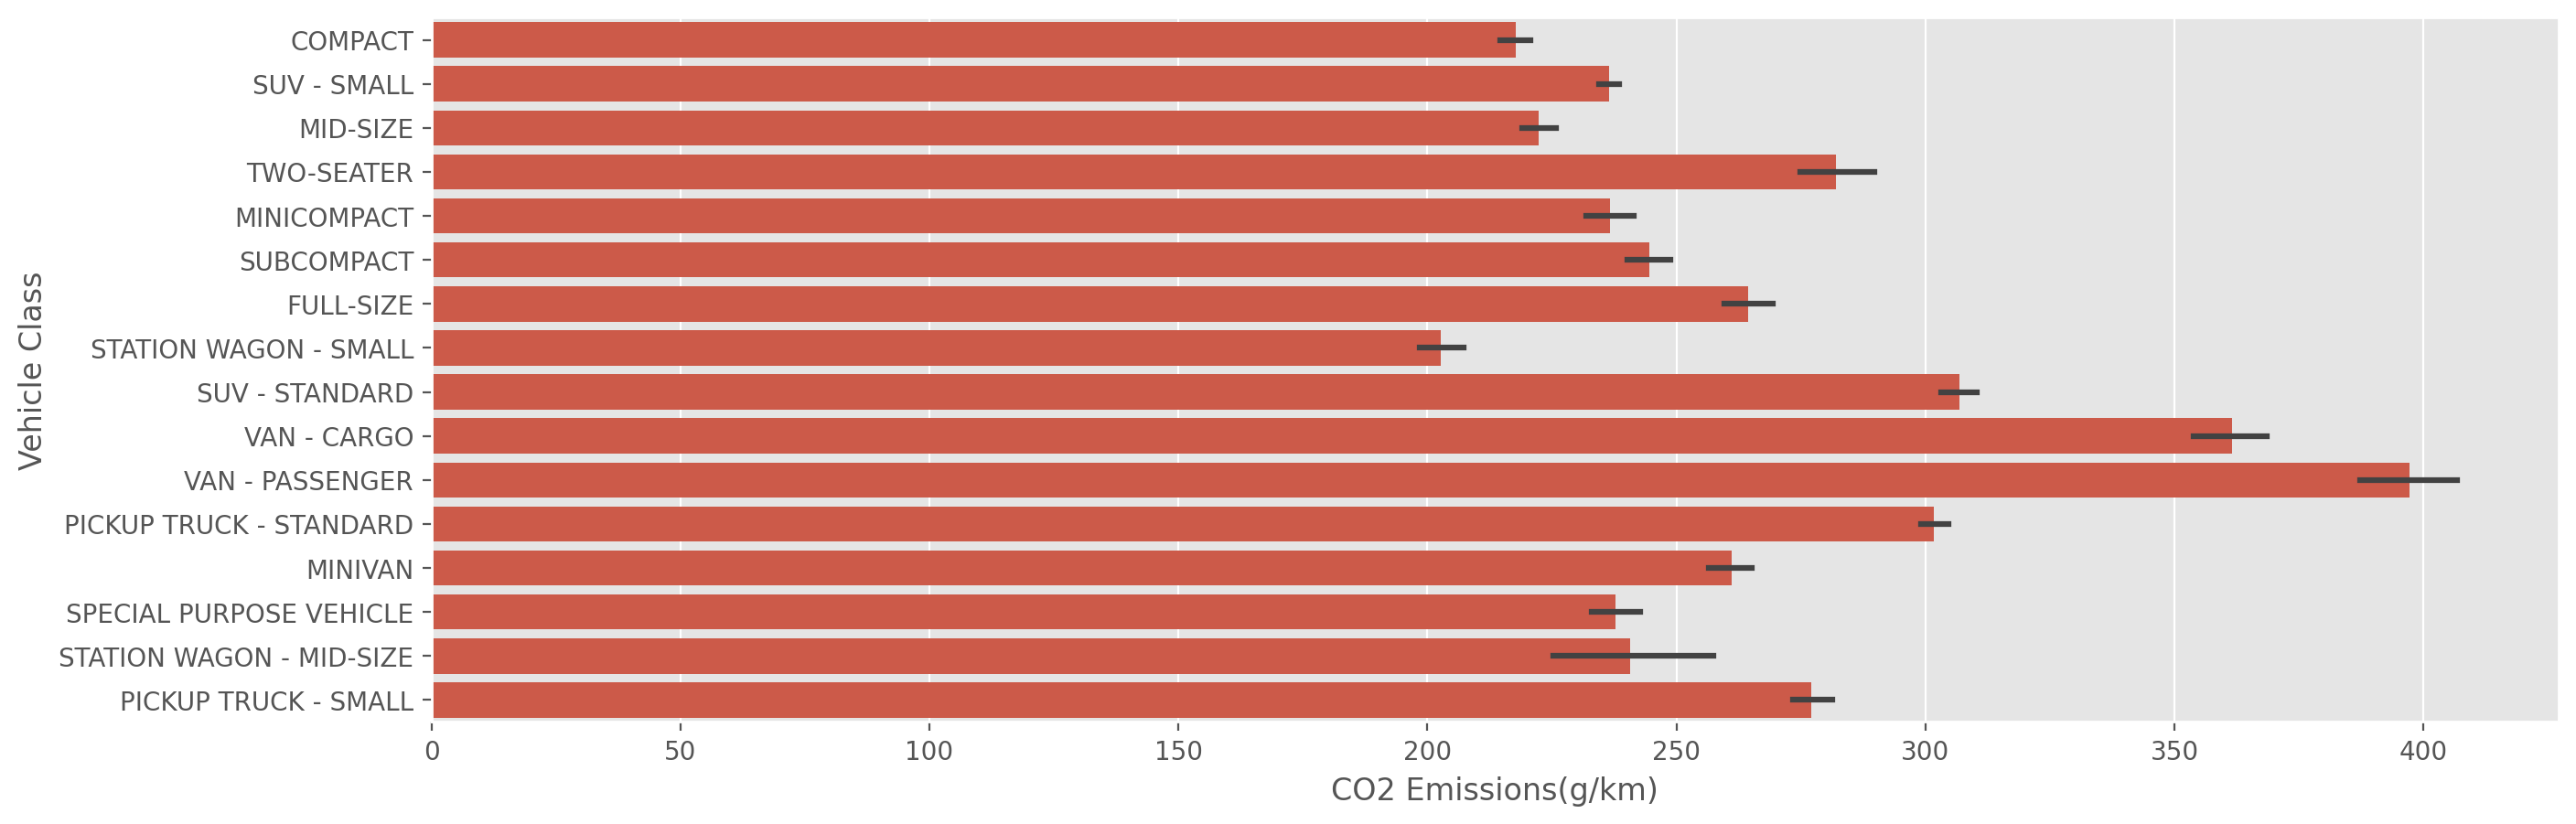

In [ ]:
# Vehical class and corbon emission

plt.figure(figsize = (15,5), dpi = 200)
sns.barplot(y = 'Vehicle Class', x = 'CO2 Emissions(g/km)', data = data)

In [ ]:
# to arrange the bard in decending orders

data.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().sort_values(ascending = False).index

Index(['VAN - PASSENGER', 'VAN - CARGO', 'SUV - STANDARD',
       'PICKUP TRUCK - STANDARD', 'TWO-SEATER', 'PICKUP TRUCK - SMALL',
       'FULL-SIZE', 'MINIVAN', 'SUBCOMPACT', 'STATION WAGON - MID-SIZE',
       'SPECIAL PURPOSE VEHICLE', 'MINICOMPACT', 'SUV - SMALL', 'MID-SIZE',
       'COMPACT', 'STATION WAGON - SMALL'],
      dtype='object', name='Vehicle Class')

In [ ]:
order = data.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().sort_values(ascending = False).index   # Saved all the index name in order

data.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().sort_values(ascending = False).index

Index(['VAN - PASSENGER', 'VAN - CARGO', 'SUV - STANDARD',
       'PICKUP TRUCK - STANDARD', 'TWO-SEATER', 'PICKUP TRUCK - SMALL',
       'FULL-SIZE', 'MINIVAN', 'SUBCOMPACT', 'STATION WAGON - MID-SIZE',
       'SPECIAL PURPOSE VEHICLE', 'MINICOMPACT', 'SUV - SMALL', 'MID-SIZE',
       'COMPACT', 'STATION WAGON - SMALL'],
      dtype='object', name='Vehicle Class')

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Vehicle Class'>

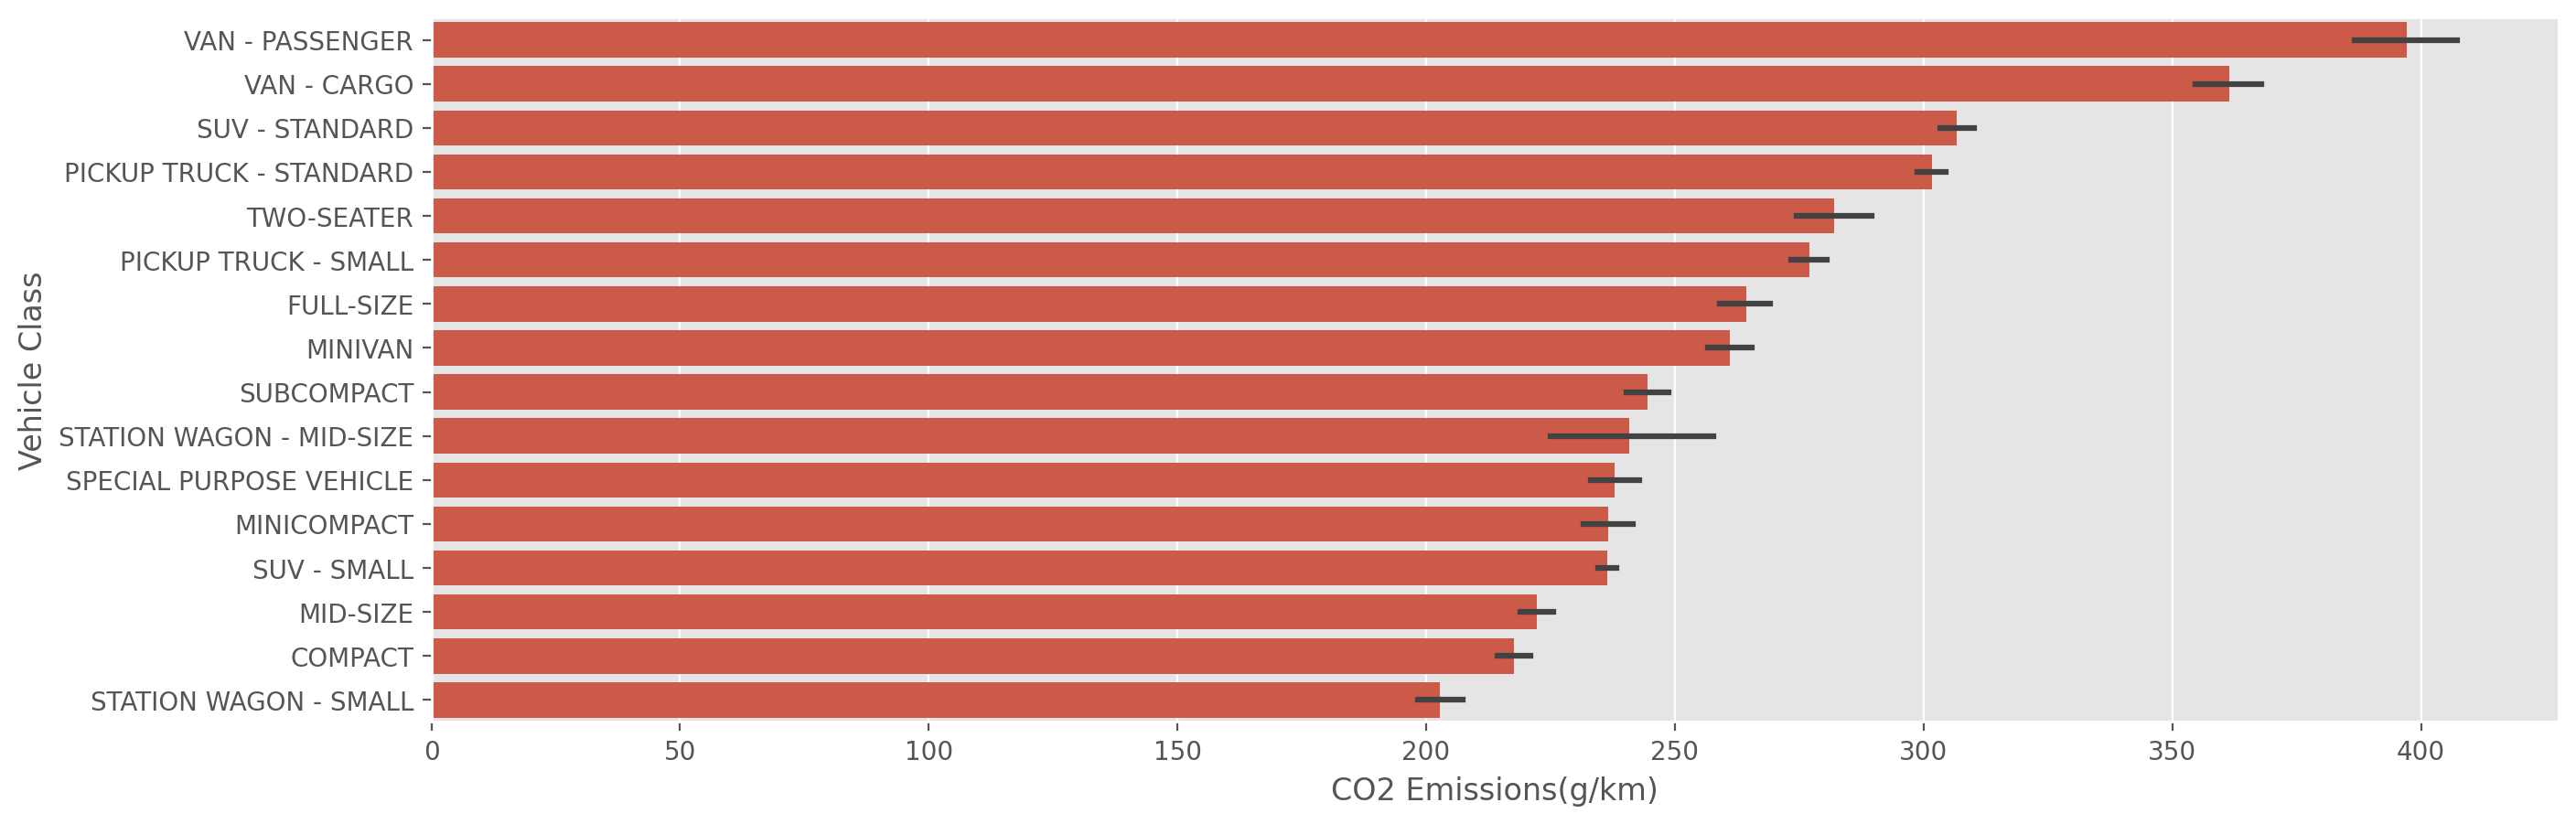

In [ ]:
# Vehical class and corbon emission in decending order

plt.figure(figsize = (15,5), dpi = 200)
sns.barplot(y = 'Vehicle Class', x = 'CO2 Emissions(g/km)',data = data, order = order)

<Axes: xlabel='CO2 Emissions(g/km)', ylabel='Make'>

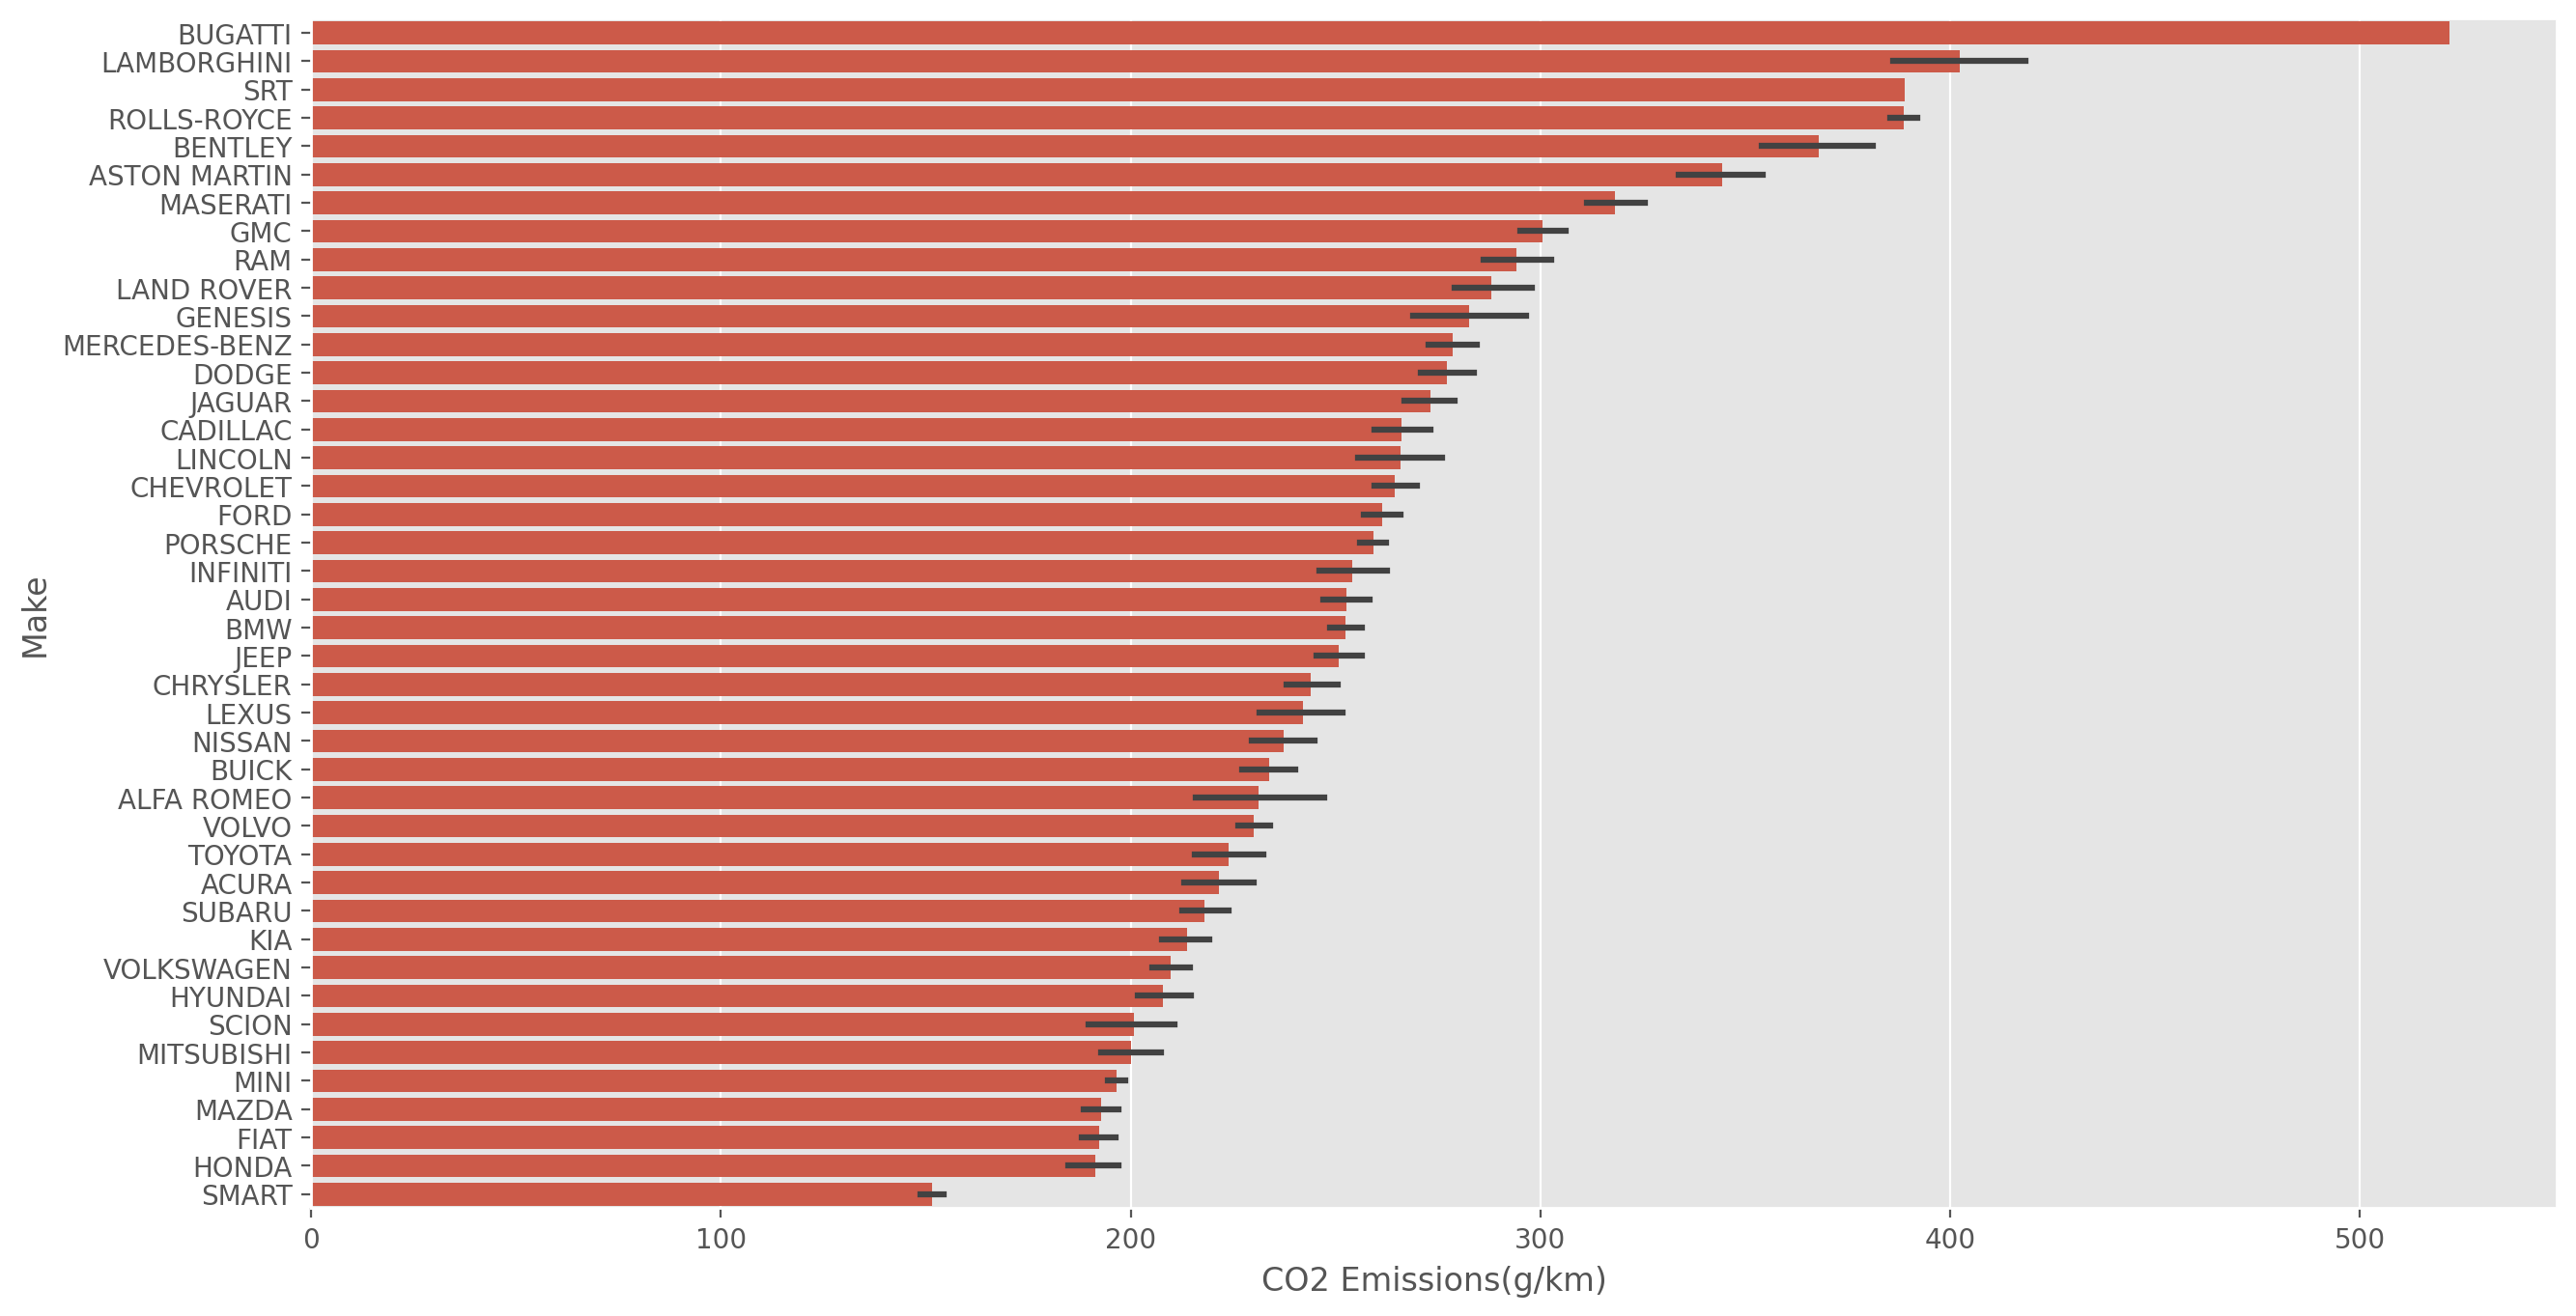

In [ ]:
# Make and corbon emission

order = data.groupby('Make')['CO2 Emissions(g/km)'].mean().sort_values(ascending = False).index

plt.figure(figsize = (15,8), dpi = 200)
sns.barplot(y = 'Make', x = 'CO2 Emissions(g/km)',data = data, order = order)

<Axes: xlabel='Cylinders', ylabel='Fuel Consumption Comb (L/100 km)'>

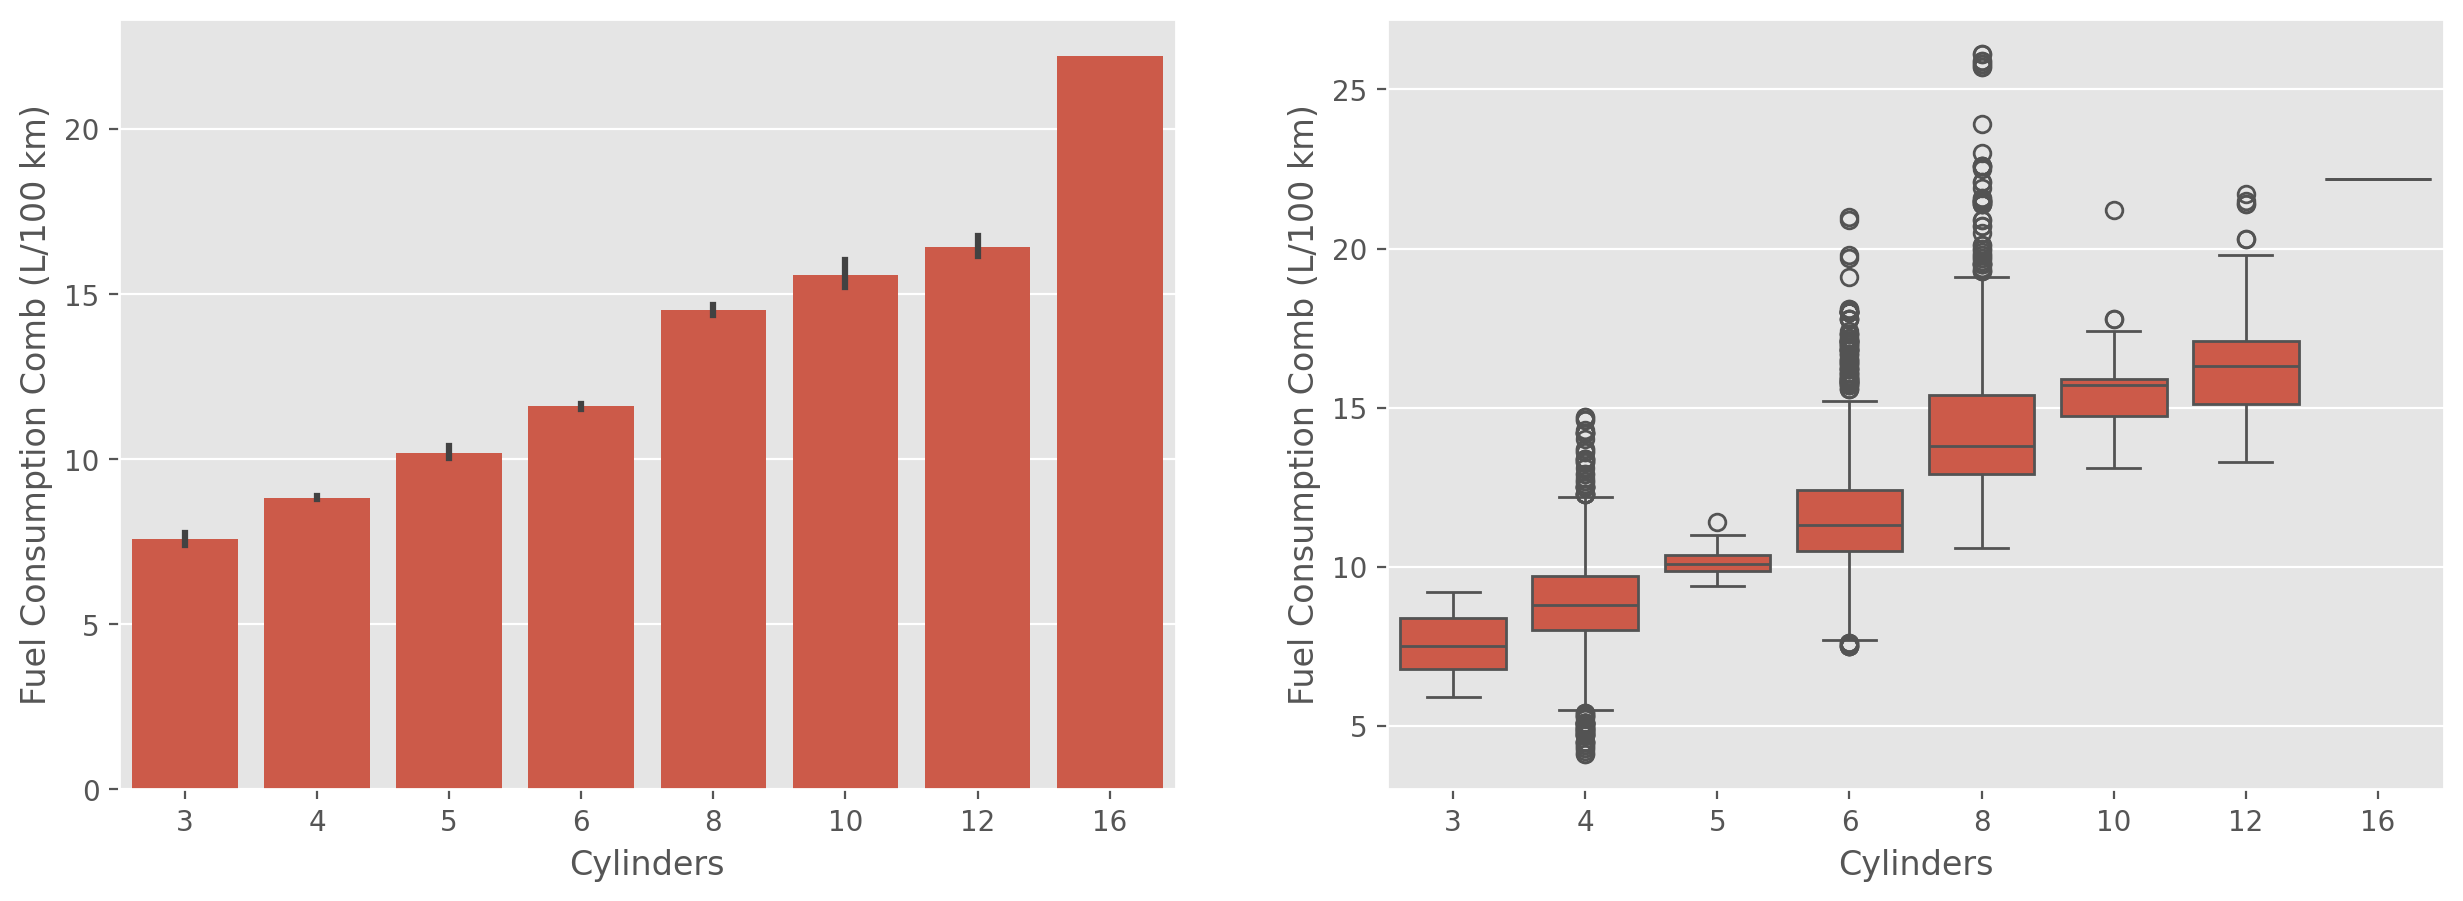

In [ ]:
# Cylinder and fuel consumption

plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.barplot(x = 'Cylinders', y = 'Fuel Consumption Comb (L/100 km)', data = data)

plt.subplot(1,2,2)
sns.boxplot(x = 'Cylinders', y = 'Fuel Consumption Comb (L/100 km)', data = data)


In [ ]:
data.groupby('Cylinders')['Fuel Consumption Comb (L/100 km)'].mean().sort_values(ascending = False)

,Fuel Consumption Comb (L/100 km)
Cylinders,
16,22.200000
12,16.423704
10,15.585000
8,14.516805
6,11.602549
5,10.196154
4,8.831903
3,7.578409


<Axes: xlabel='Fuel Type', ylabel='Fuel Consumption Comb (L/100 km)'>

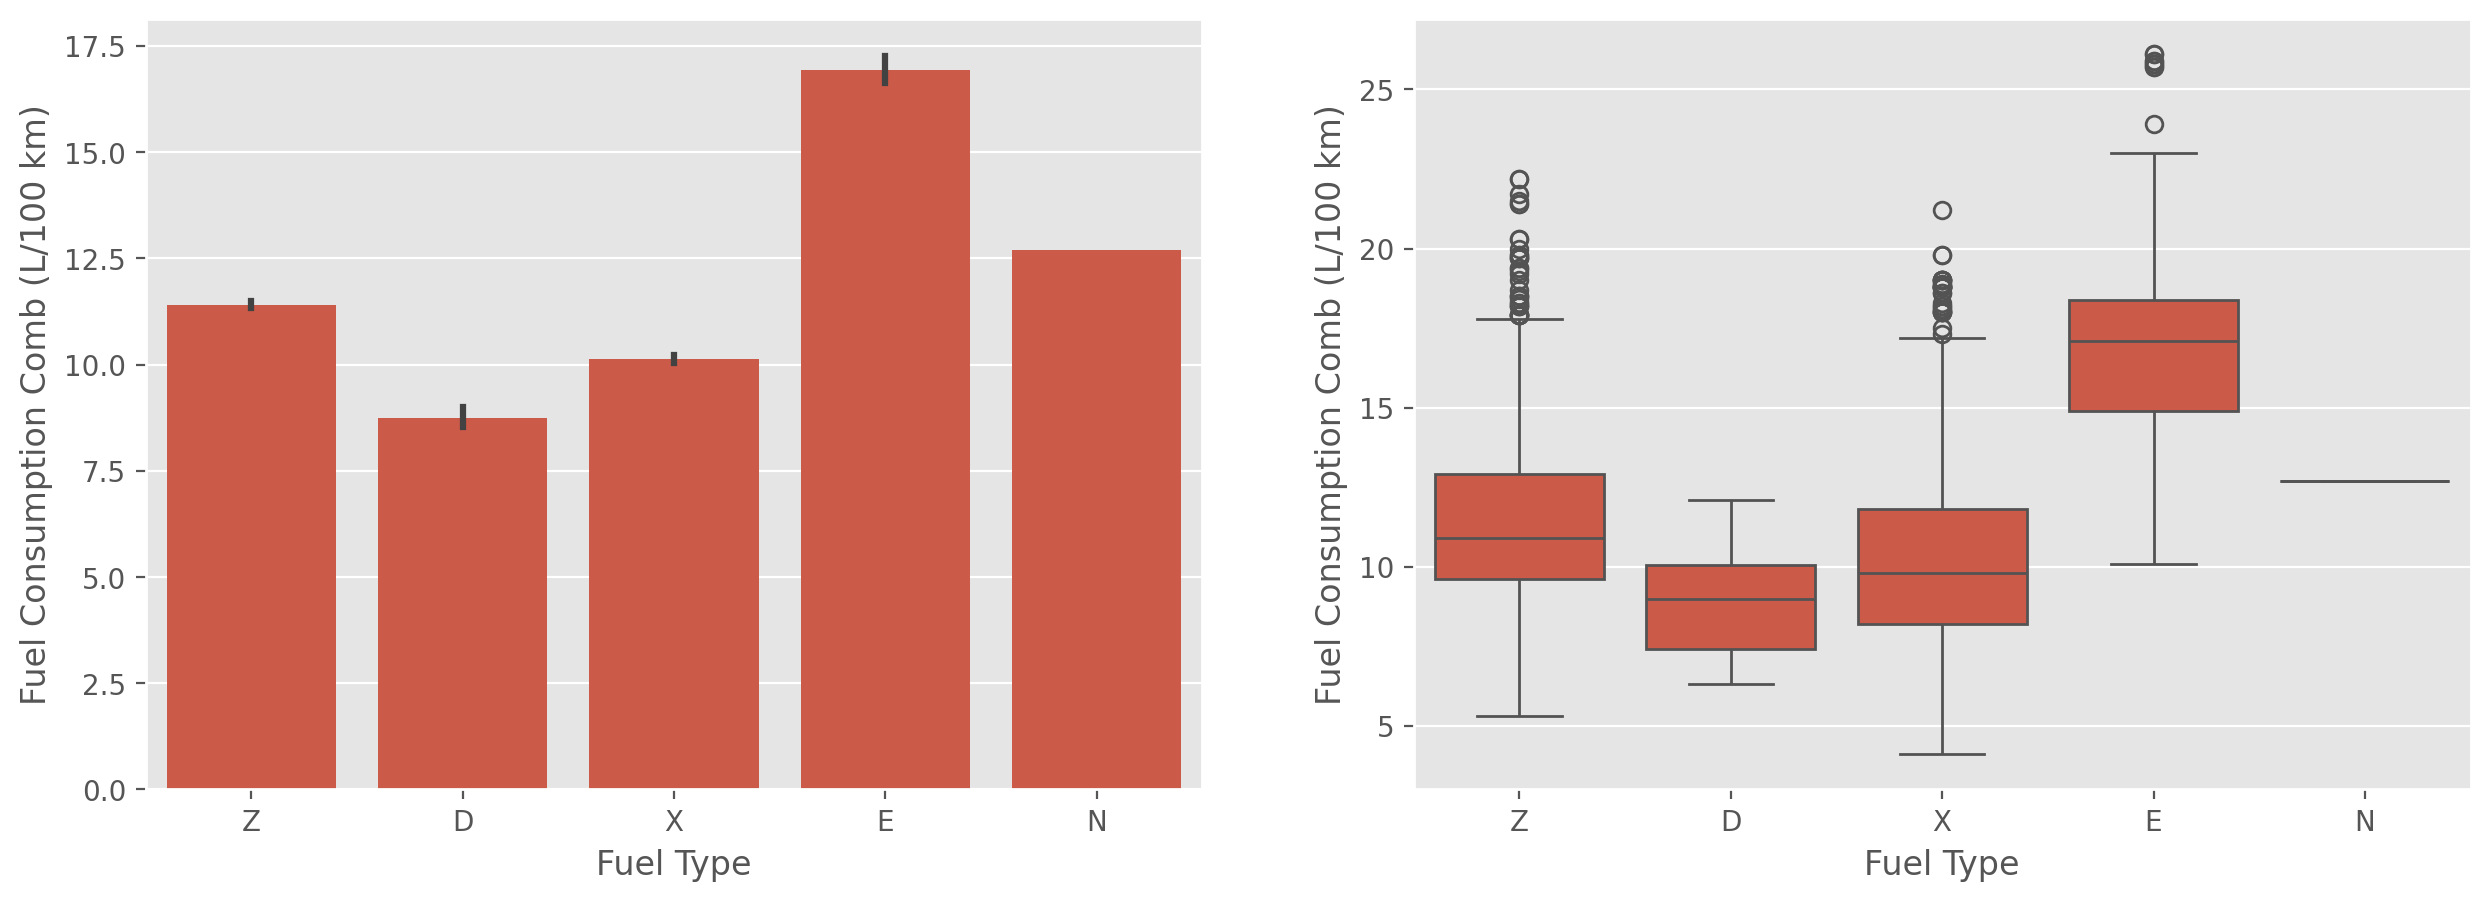

In [ ]:
# Fuel Type and fuel consumption

plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.barplot(x = 'Fuel Type', y = 'Fuel Consumption Comb (L/100 km)', data = data)

plt.subplot(1,2,2)
sns.boxplot(x = 'Fuel Type', y = 'Fuel Consumption Comb (L/100 km)', data = data)

<Axes: ylabel='CO2 Emissions(g/km)'>

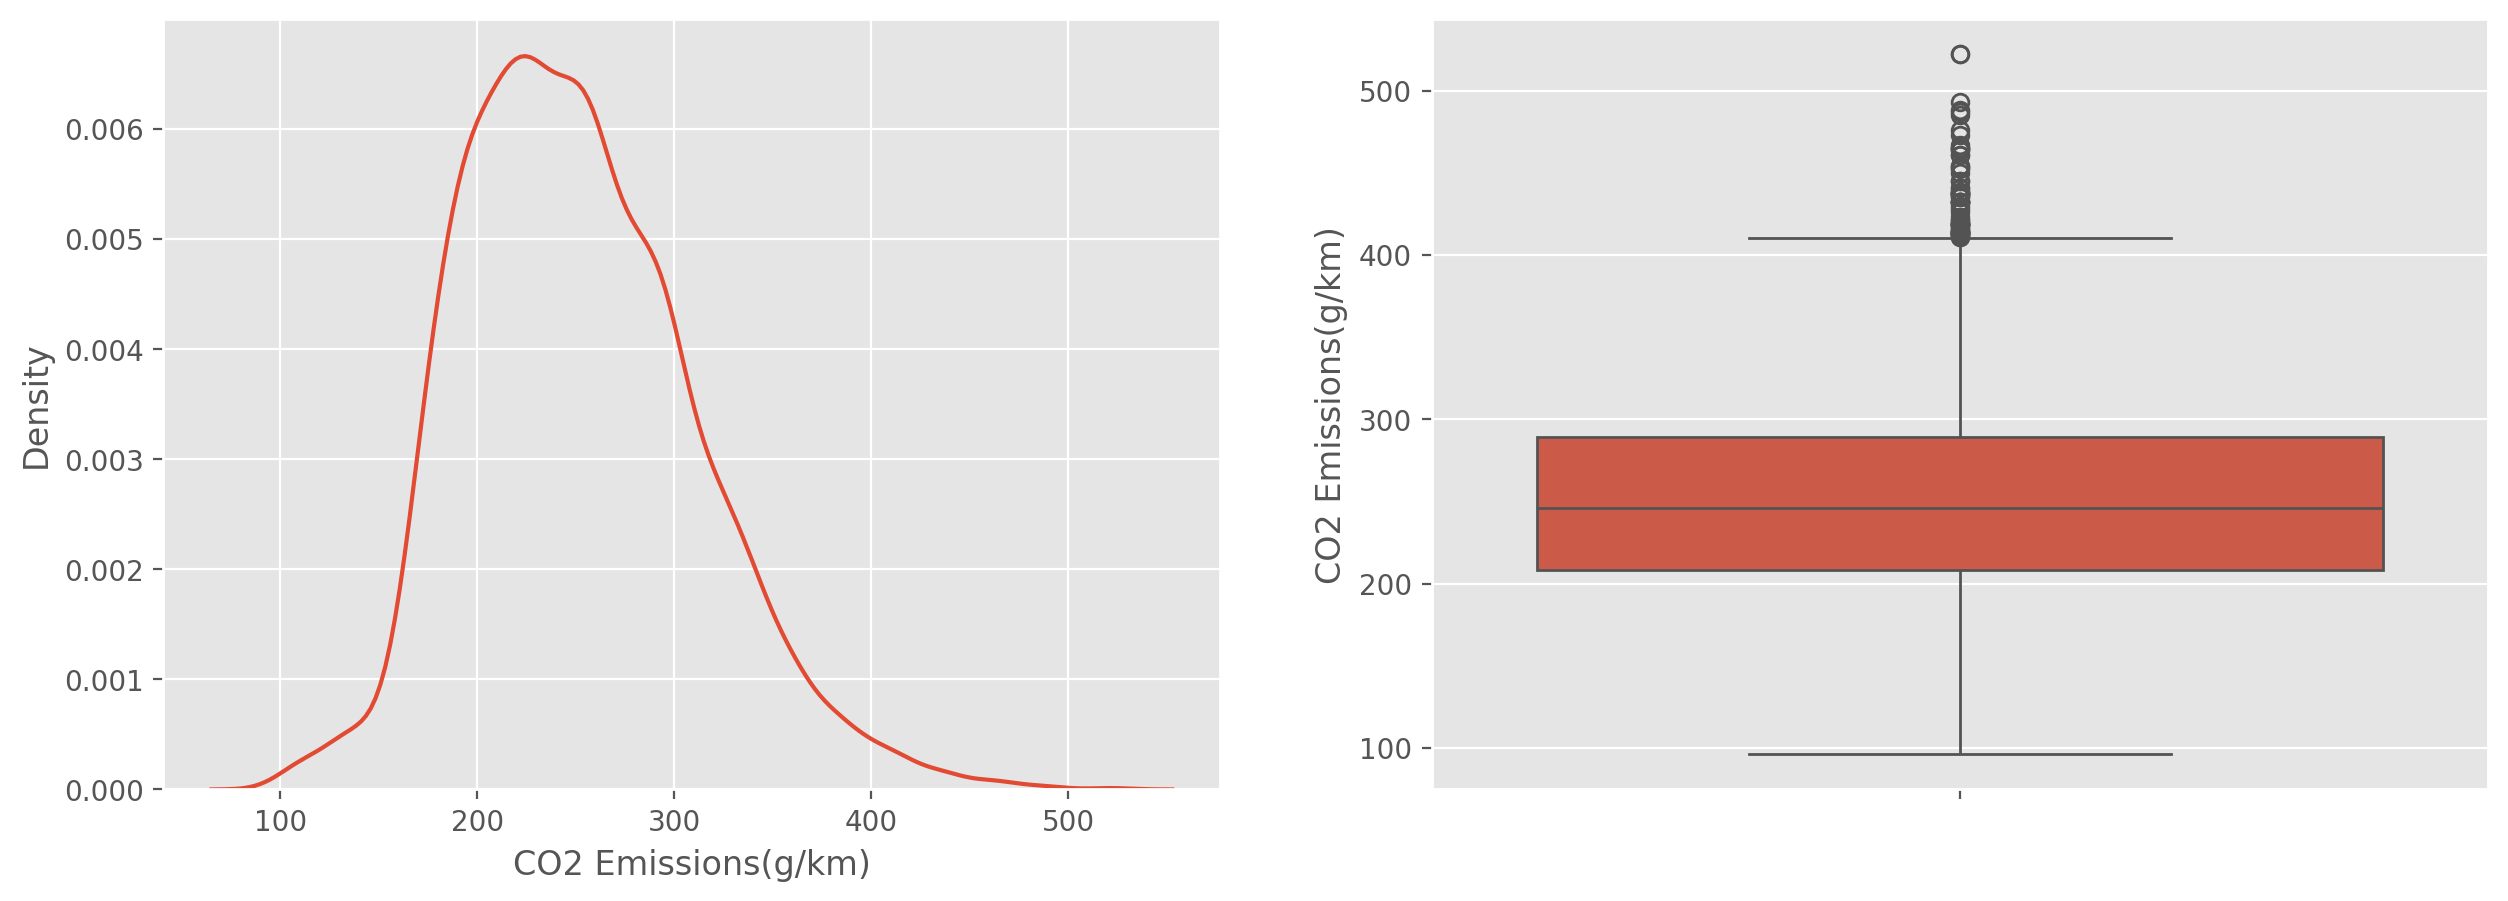

In [ ]:
# Co2 Emission

plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.distplot(data['CO2 Emissions(g/km)'],hist = False)

plt.subplot(1,2,2)
sns.boxplot(data['CO2 Emissions(g/km)'])


<Axes: ylabel='Fuel Consumption Comb (L/100 km)'>

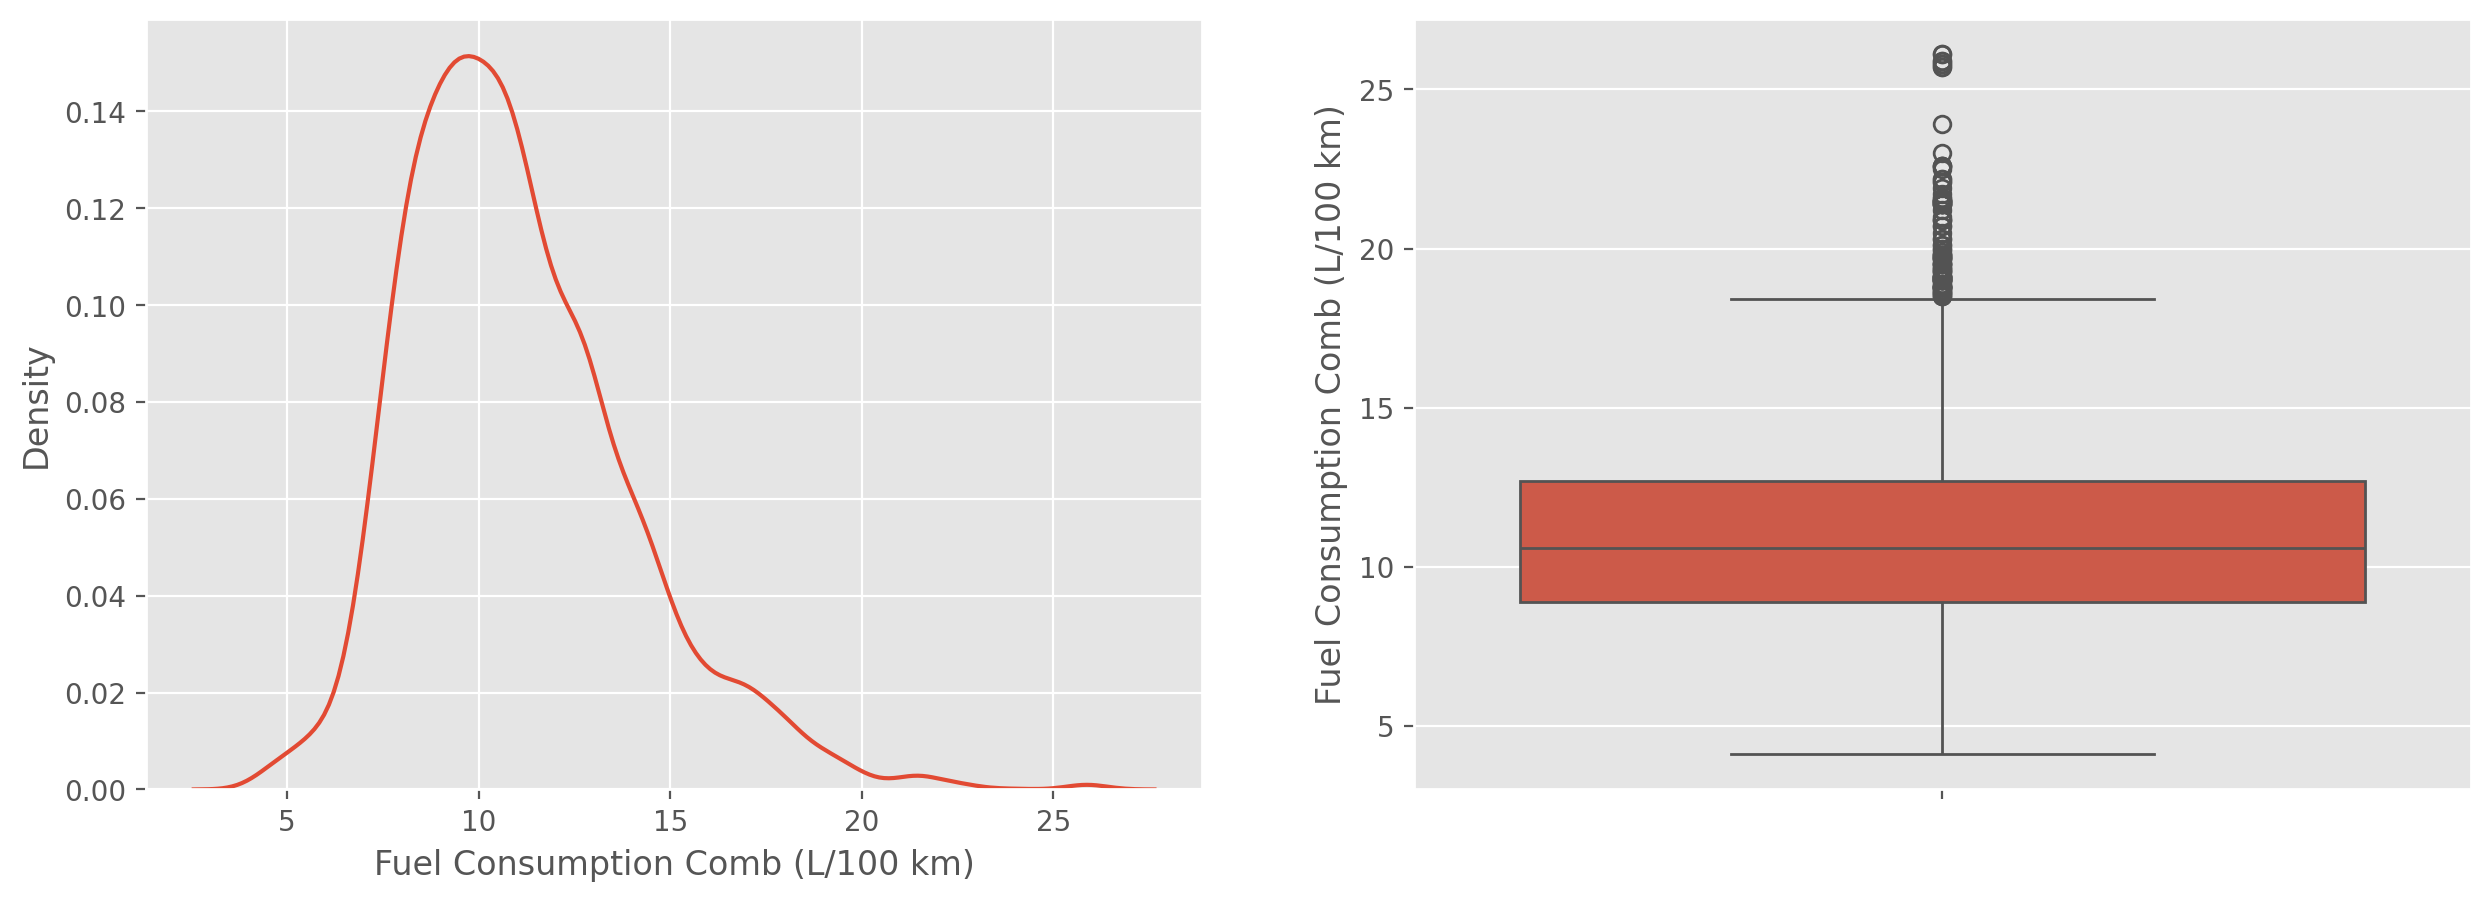

In [ ]:
# Fuel Consumption

plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.distplot(data['Fuel Consumption Comb (L/100 km)'],hist = False)

plt.subplot(1,2,2)
sns.boxplot(data['Fuel Consumption Comb (L/100 km)'])


<Axes: xlabel='Cylinders', ylabel='count'>

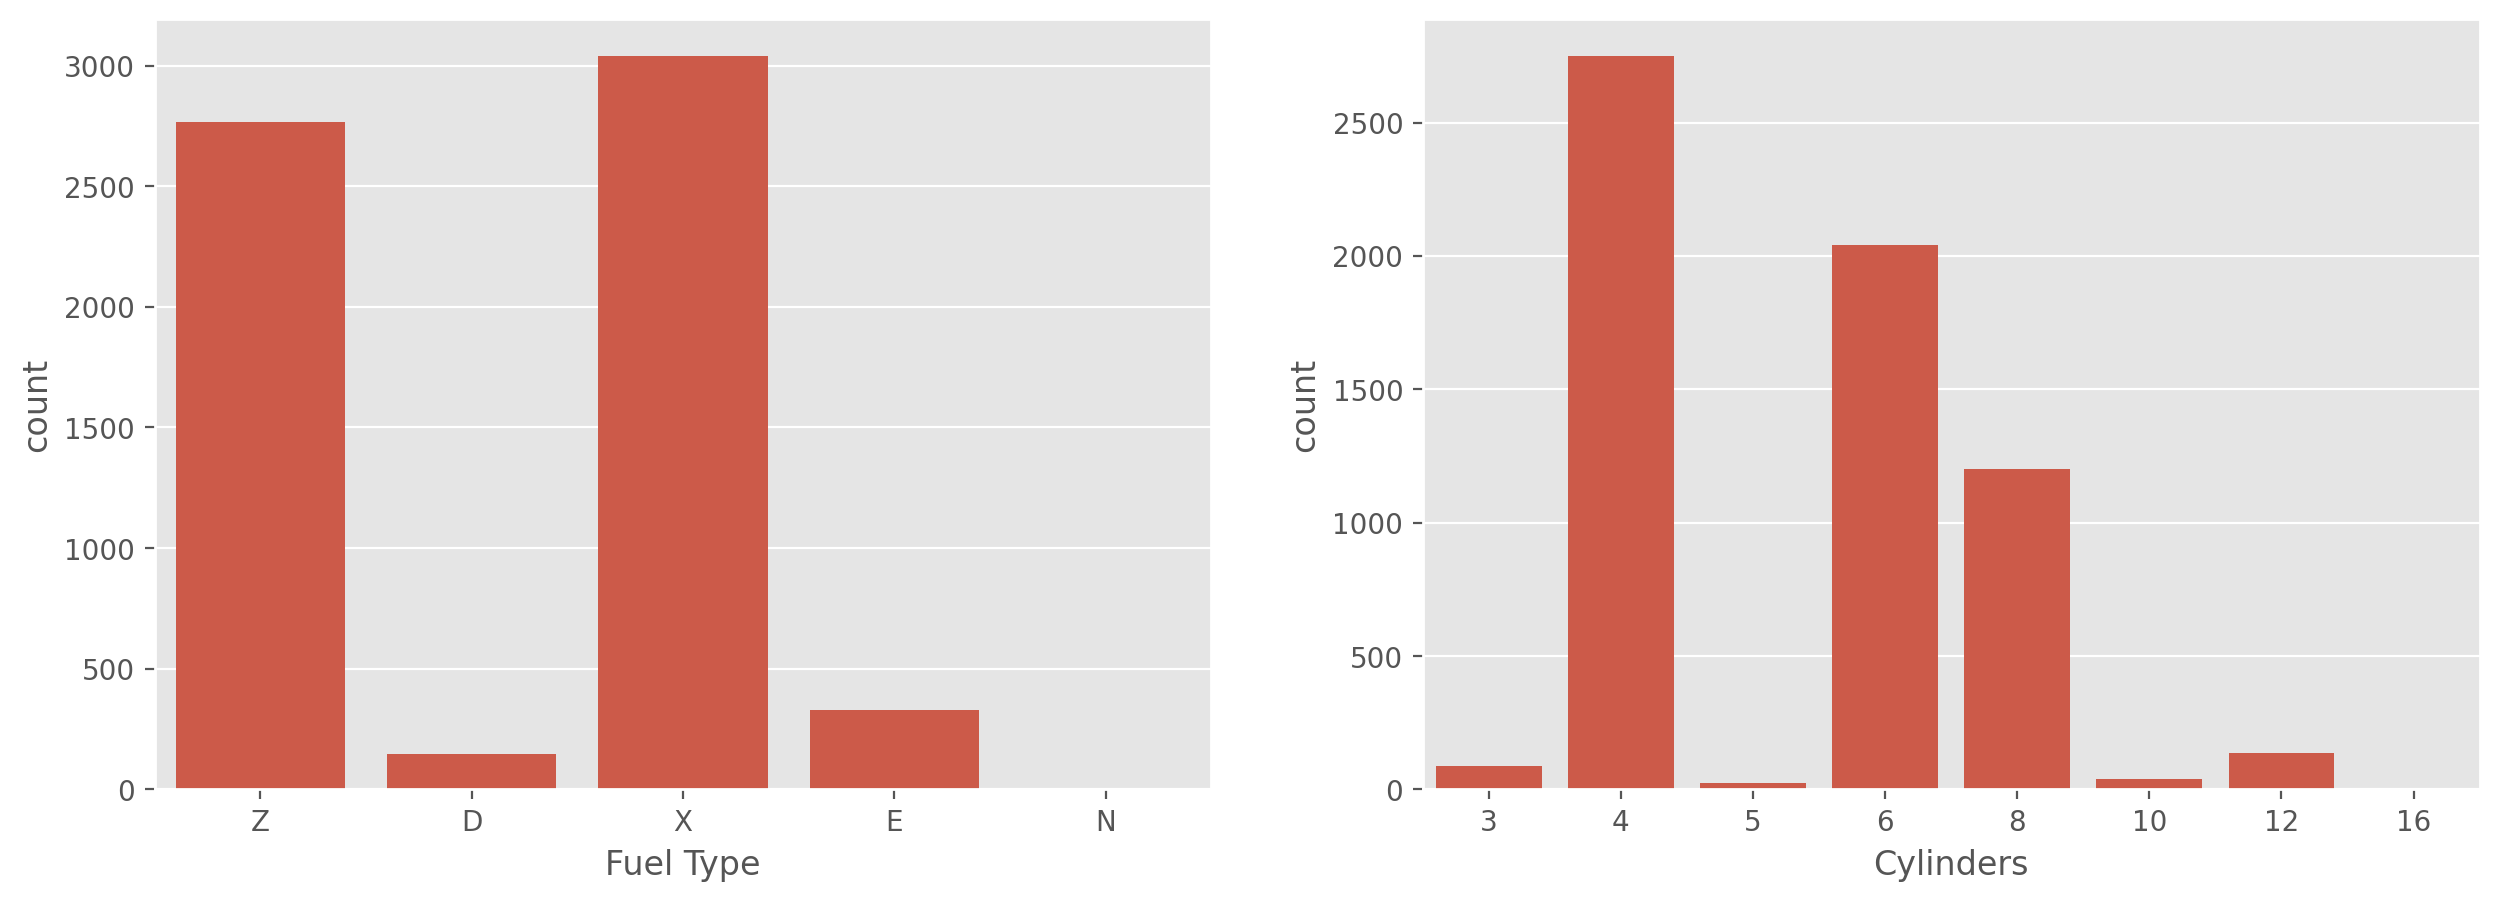

In [ ]:
plt.figure(figsize = (15,5), dpi = 200)

plt.subplot(1,2,1)
sns.countplot(x = data['Fuel Type'])

plt.subplot(1,2,2)
sns.countplot(x = data['Cylinders'])

In [ ]:
data['Cylinders'].value_counts()

,count
Cylinders,
4,2749
6,2040
8,1202
12,135
3,88
10,40
5,26
16,2


In [ ]:
data['Fuel Type'].value_counts()

,count
Fuel Type,
X,3039
Z,2765
E,330
D,147
N,1


<Axes: xlabel='count', ylabel='Make'>

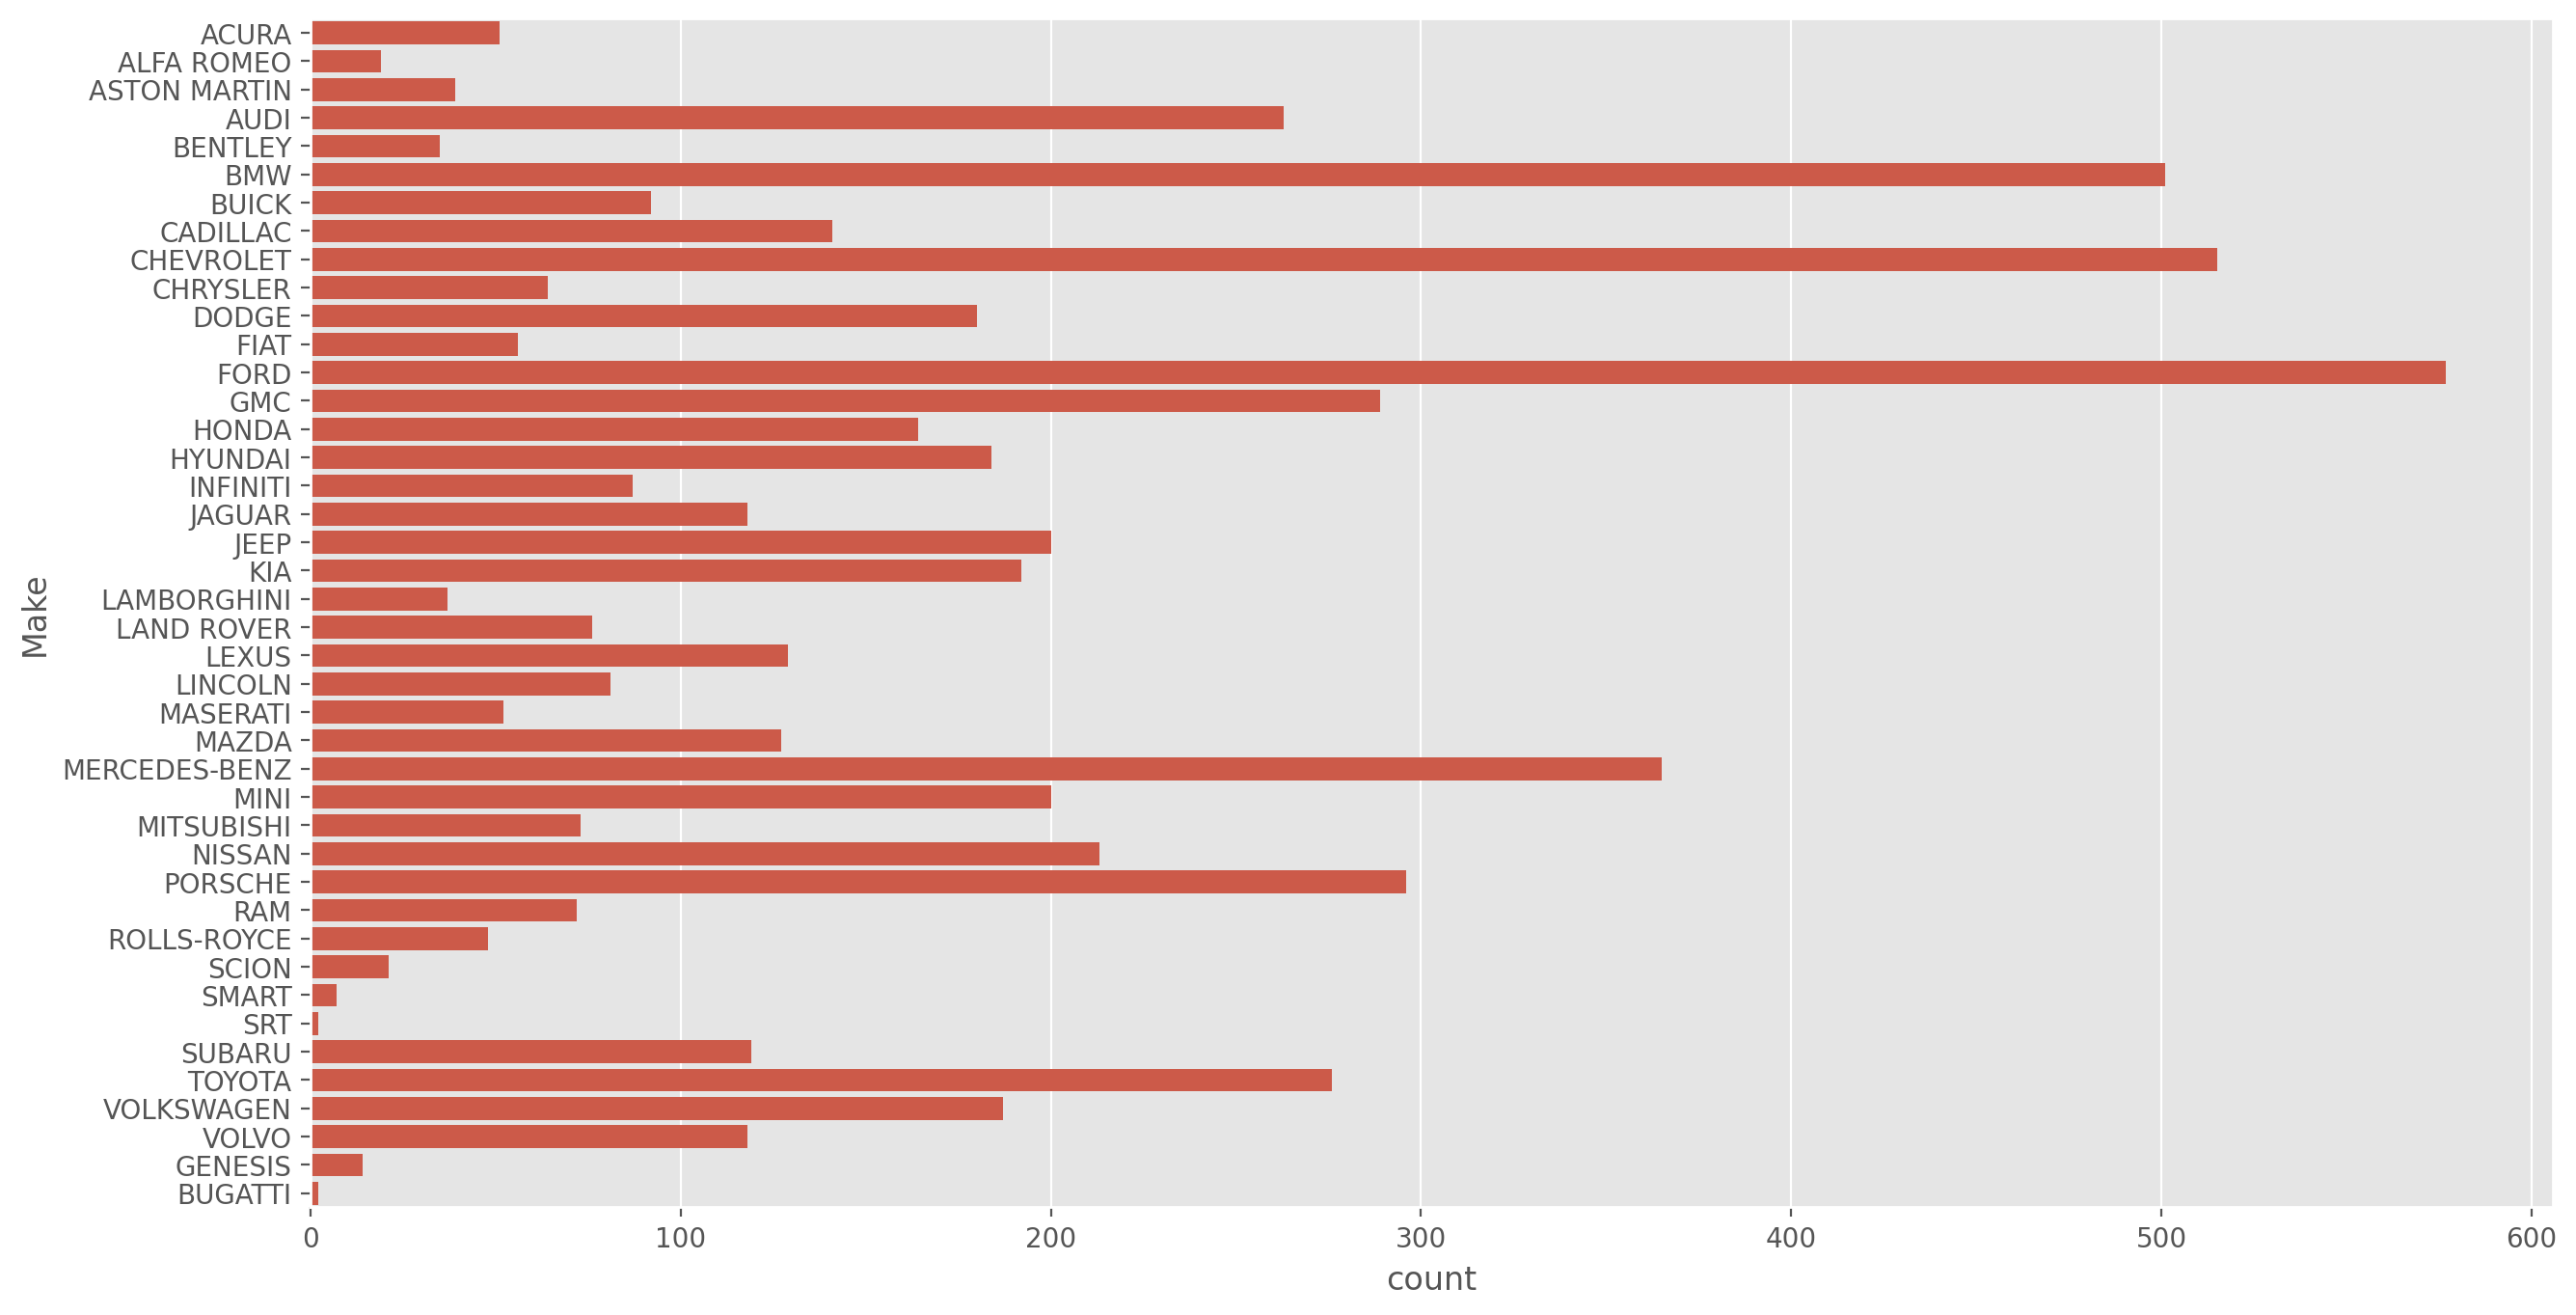

In [ ]:
# which is most popular manufacturer is popular

plt.figure(figsize = (15,8), dpi = 200)
sns.countplot(y = data['Make'])

<Axes: xlabel='count', ylabel='Make'>

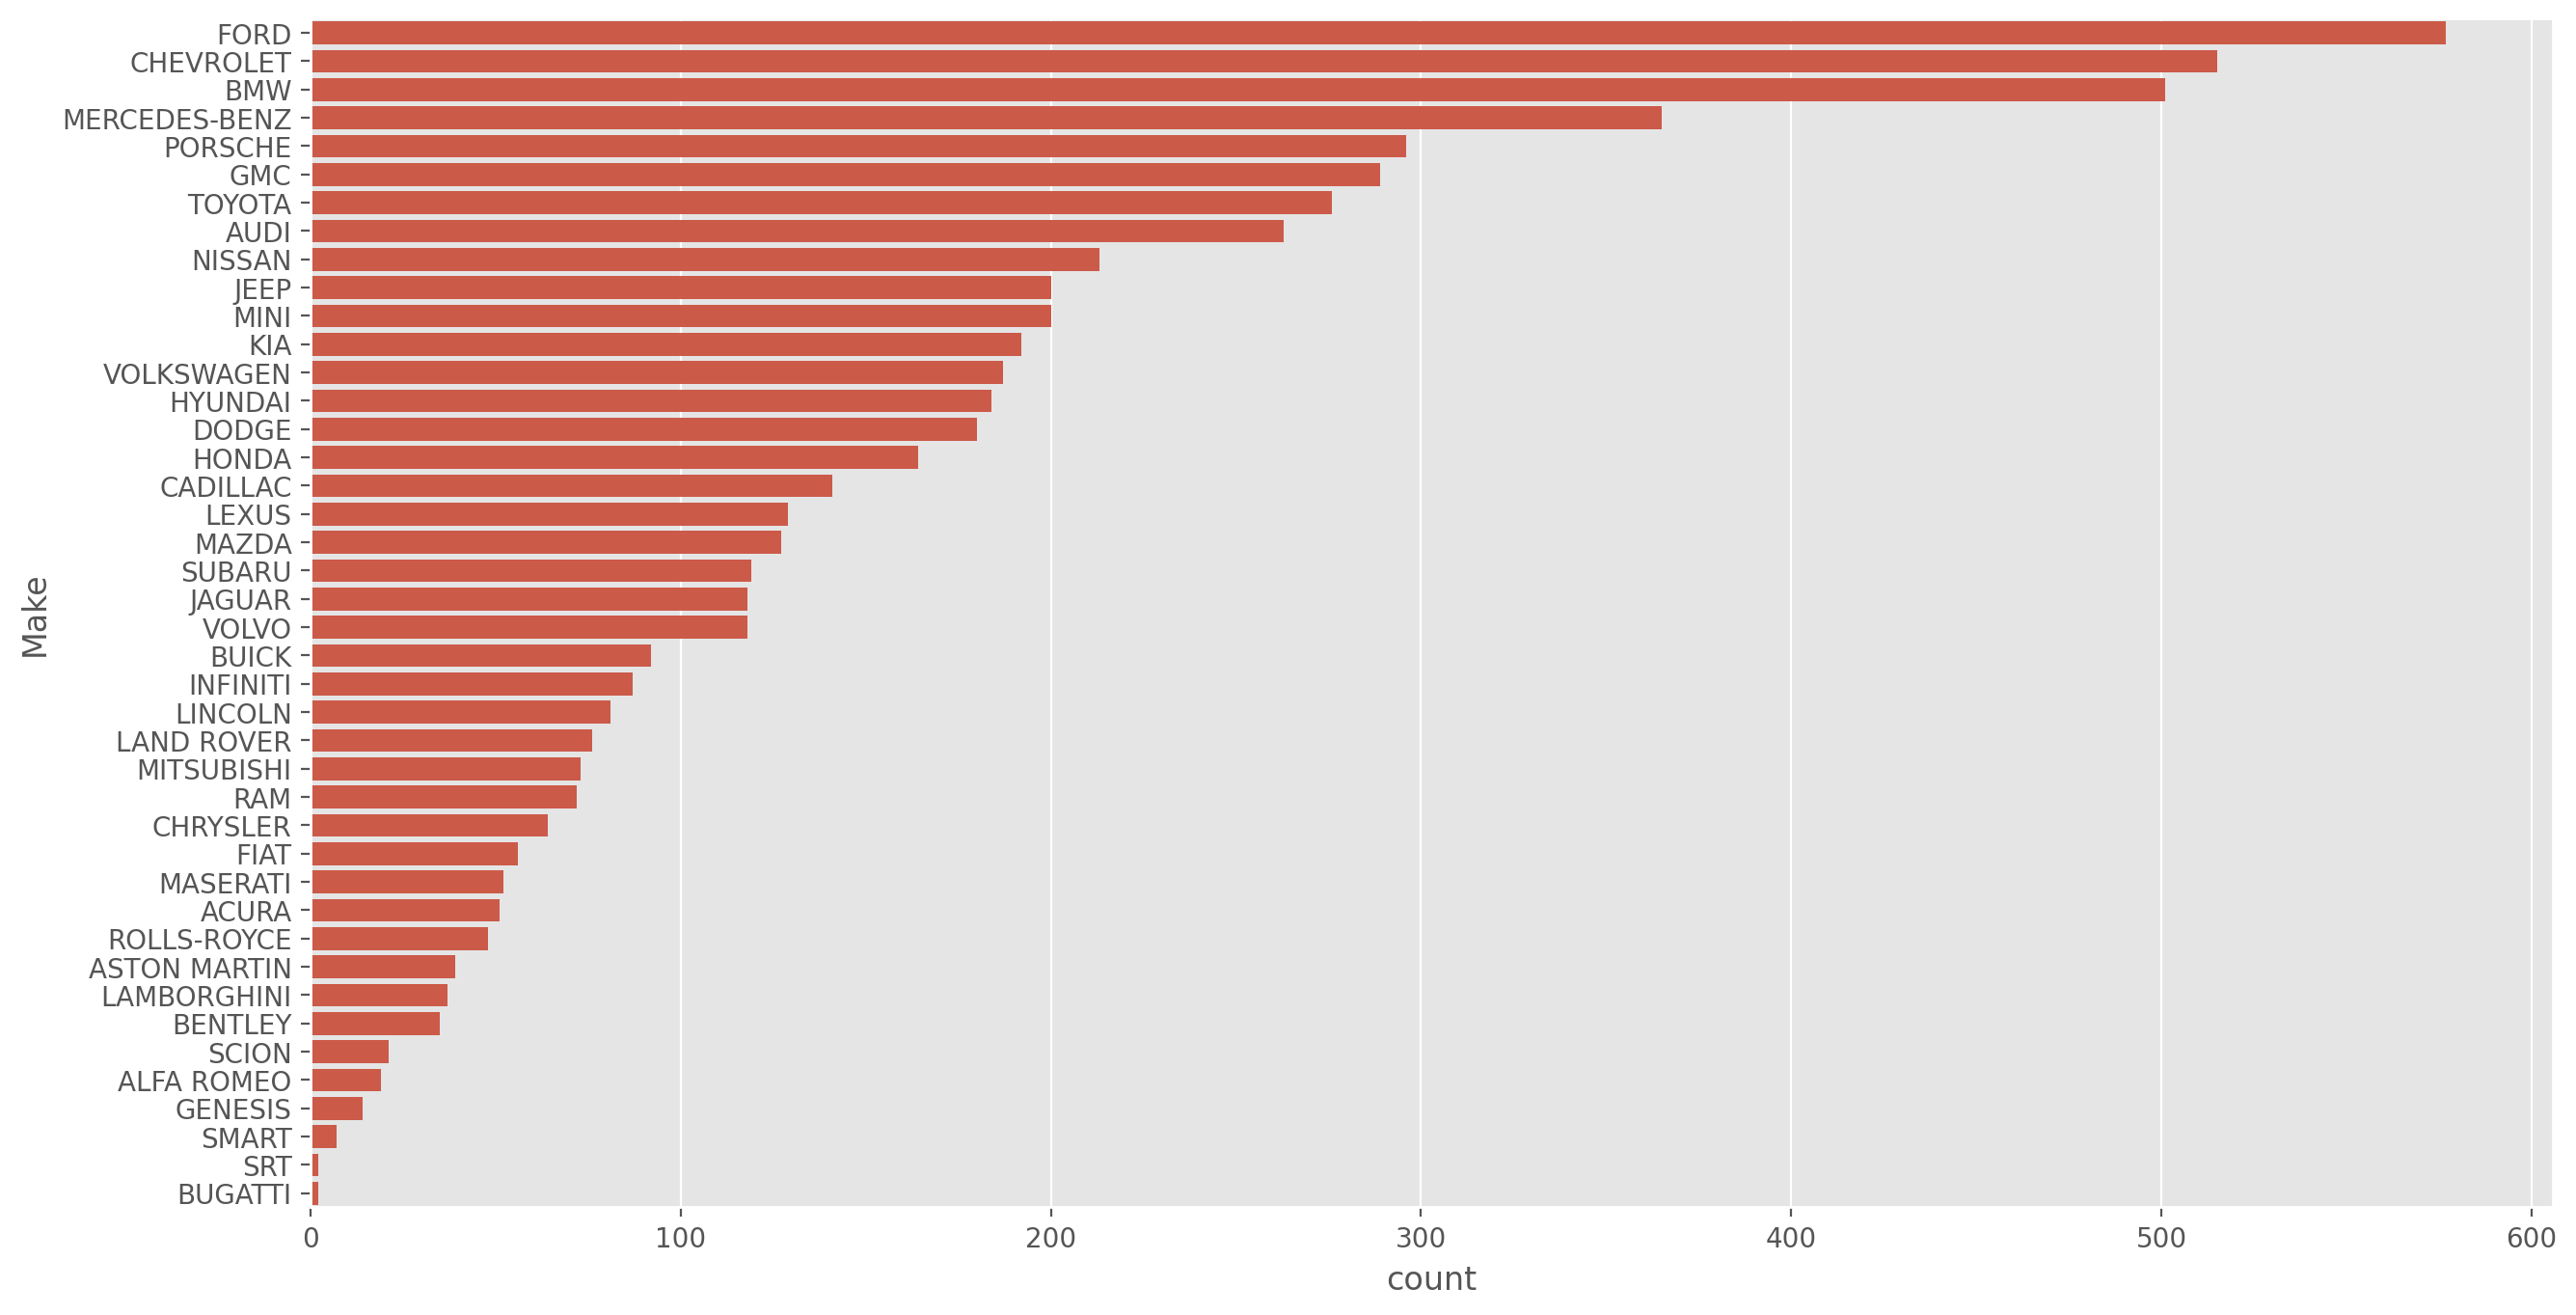

In [ ]:
# To arrange in descending order

plt.figure(figsize = (15,8), dpi = 200)
sns.countplot(y = data['Make'], order = data['Make'].value_counts().index)



---



---



---

